# PR Metrics — Journal Visualization Notebook

Esta é a versão journal do notebook de visualizações, construída sobre o `prs_viz_bp_paper.ipynb` (versão conferência).

## Principais diferenças em relação à versão conferência

| Aspecto | Versão Conferência | Versão Journal |
|---|---|---|
| LOC / Files | Histograma de 1 repo + linhas de mediana dos demais | Violin plots lado a lado de todos os repositórios |
| Refactoring | Histograma de 1 repo + linhas de mediana | Violin plots de todos os repositórios |
| Pace | Heatmap (mantido) | Heatmap revisado com melhorias de legibilidade |
| Knowledge Transfer | Gráfico de linha para BP apenas | Análise multi-repositório com comparação |

## Por que violin plots em vez de histogramas?

A versão conferência apresenta o histograma de distribuição do repositório Brasil Participativo (BP)
com **linhas verticais** indicando a mediana de cada grupo de comparação. Esse design tem limitações:

1. **Redução informacional**: a mediana de um único ponto não revela dispersão, assimetria,
   bimodalidade nem caudas longas. Dois grupos com a mesma mediana podem ter distribuições radicalmente diferentes.
2. **Foco assimétrico**: toda a área visual é dominada pela distribuição do BP; os grupos
   comparados aparecem apenas como linhas finas, impossibilitando julgamento visual das suas distribuições.
3. **Escalabilidade**: com 11 repositórios, empilhar 10 linhas verticais em um mesmo histograma
   produz ruído visual em vez de insight.

O violin plot corrige esses problemas ao exibir a **densidade estimada completa** de cada grupo
lado a lado, com mediana e quartis internos, permitindo comparação simultânea de forma, centro e dispersão.
Complementado por escala logarítmica (onde aplicável), lida naturalmente com as distribuições
fortemente assimétricas típicas de métricas de software.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats

# ── Publication-quality global settings ─────────────────────────────────────
sns.set_context('paper', font_scale=1.25)
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.constrained_layout.use': True,
})

# ── Color palette ─────────────────────────────────────────────────────────────
# BP (government/industry): navy blue
# Academic: three shades of teal
# Market: seven shades of orange/amber
GROUP_COLORS = {
    'Brasil Participativo': '#0B3C5D',
    'MDS (Academic)':       '#1B998B',
    'REQ (Academic)':       '#2DC7B4',
    'EPS (Academic)':       '#7EE8A2',
    'Decidim (Market)':     '#E07B14',
    'VSCode (Market)':      '#D55E00',
    'React (Market)':       '#F0AB44',
    'Storm (Market)':       '#A0522D',
    'Phoenix (Market)':     '#9B59B6',
    'PulpCore (Market)':    '#C0392B',
    'Quay (Market)':        '#E74C3C',
}

# Category-level colors (used for heatmaps and reference)
BP_PRIMARY    = '#0B3C5D'
ACAD_PRIMARY  = '#1B998B'
MKT_PRIMARY   = '#E07B14'

# ── Data path ─────────────────────────────────────────────────────────────────
# From journal/data/silver/prs.csv
DATA_PATH = Path('data') / 'silver' / 'prs.csv'

# ── Output directory ──────────────────────────────────────────────────────────
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

print(f'Data file: {DATA_PATH.resolve()}')
print(f'Figures  : {FIGURES_DIR.resolve()}')

Data file: /home/tiagobitt/projects/EbL_Over_PbL/journal/data/silver/prs.csv
Figures  : /home/tiagobitt/projects/EbL_Over_PbL/journal/figures


In [2]:
# ── Bot detection ─────────────────────────────────────────────────────────────
BOT_KEYWORDS = [
    'bot', 'dependabot', 'renovate', 'github-actions', 'codecov',
    'greenkeeper', 'snyk', 'pyup', 'automated', 'ci-', 'action',
    'github-advanced-security', 'copilot-pull-request',
]

def is_bot(author: str) -> bool:
    if pd.isna(author):
        return False
    return any(kw in str(author).lower() for kw in BOT_KEYWORDS)


# ── Raw load ──────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH)

# ── Group definitions ─────────────────────────────────────────────────────────
# Each entry: (label, mask_fn)
GROUP_DEFS = {
    'Brasil Participativo': lambda d: (d['org'] == 'lappis-unb/decidimbr') & (d['repo'] == 'decidim-govbr'),
    'MDS (Academic)':       lambda d: d['org'] == 'unb-mds',
    'REQ (Academic)':       lambda d: d['org'] == 'mdsreq-fga-unb',
    'EPS (Academic)':       lambda d: d['org'] == 'fga-eps-mds',
    'Decidim (Market)':     lambda d: d['org'] == 'decidim',
    'VSCode (Market)':      lambda d: (d['org'] == 'microsoft') & (d['repo'] == 'vscode'),
    'React (Market)':       lambda d: (d['org'] == 'facebook') & (d['repo'] == 'react'),
    'Storm (Market)':       lambda d: (d['org'] == 'apache') & (d['repo'] == 'storm'),
    'Phoenix (Market)':     lambda d: (d['org'] == 'apache') & (d['repo'] == 'phoenix'),
    'PulpCore (Market)':    lambda d: (d['org'] == 'pulp') & (d['repo'] == 'pulpcore'),
    'Quay (Market)':        lambda d: (d['org'] == 'quay') & (d['repo'] == 'quay'),
}

# ── Build per-group DataFrames (bots removed) ─────────────────────────────────
groups: dict[str, pd.DataFrame] = {}
for label, mask_fn in GROUP_DEFS.items():
    subset = df_raw[mask_fn(df_raw)].copy()
    groups[label] = subset[~subset['author'].apply(is_bot)].copy()

# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for label, mask_fn in GROUP_DEFS.items():
    full    = df_raw[mask_fn(df_raw)]
    no_bots = groups[label]
    rows.append({
        'Group':        label,
        'Category':     label.split('(')[-1].rstrip(')') if '(' in label else 'Government',
        'PRs (total)':  len(full),
        'PRs (no bots)': len(no_bots),
        'Bots removed (%)': f"{(len(full)-len(no_bots))/len(full)*100:.1f}" if len(full) else '—',
    })

summary = pd.DataFrame(rows)
display(summary)
print(f"\nTotal PRs (no bots): {summary['PRs (no bots)'].sum():,}")

,Group,Category,PRs (total),PRs (no bots),Bots removed (%)
0,Brasil Participativo,Government,511,511,0.0
1,MDS (Academic),Academic,351,347,1.1
2,REQ (Academic),Academic,231,231,0.0
3,EPS (Academic),Academic,229,229,0.0
4,Decidim (Market),Market,2178,1552,28.7
5,VSCode (Market),Market,15020,14945,0.5
6,React (Market),Market,2610,2587,0.9
7,Storm (Market),Market,297,53,82.2
8,Phoenix (Market),Market,350,350,0.0
9,PulpCore (Market),Market,1433,685,52.2



Total PRs (no bots): 22,254


---
## 1  LOC and Files Modified

### Design rationale

Software size metrics (LOC added, LOC removed, churn, files changed) seguem distribuições
**fortemente assimétricas à direita** com caudas longas, um padrão bem documentado na literatura
(Herraiz et al., 2013). Para capturar adequadamente essas características:

- **Violin + box interno**: o violino exibe a densidade estimada (KDE), enquanto a caixa interna
  mostra Q1, mediana e Q3, permitindo leitura simultânea de forma e resumo numérico.
- **Escala logarítmica (base 10)**: comprime as caudas longas sem descartar outliers,
  preservando a interpretação em escala original via labels no eixo.
- **Clipping para display**: os violinos são calculados sobre os dados brutos mas exibidos
  até o percentil 99 para evitar que outliers extremos colem a distribuição principal
  ao fundo do gráfico. O valor do clipping é anotado.
- **Ordenação por mediana**: facilita ranking visual imediato entre repositórios.
- **Paleta consistente**: as mesmas cores são usadas em todas as figuras deste notebook.

In [3]:
def build_long_df(groups: dict, metric: str, min_value: float = 0) -> pd.DataFrame:
    """Assemble a long-format DataFrame with one row per PR, filtered to metric > min_value."""
    frames = []
    for label, df in groups.items():
        col = df[metric].dropna()
        col = col[col > min_value]
        frames.append(pd.DataFrame({'group': label, 'value': col.values}))
    return pd.concat(frames, ignore_index=True)


def category_color(label: str) -> str:
    """Map a group label to its category color (BP / Academic / Market)."""
    if 'Participativo' in label:
        return BP_PRIMARY
    if 'Academic' in label:
        return ACAD_PRIMARY
    return MKT_PRIMARY


def plot_violin(
    groups: dict,
    metric: str,
    xlabel: str,
    title: str,
    log_scale: bool = True,
    clip_pct: float = 99,
    min_value: float = 0,
    figsize: tuple = (12, 5),
    save_path: Path | None = None,
) -> plt.Figure:
    """
    Generic violin-plot function for a single metric across all repository groups.

    Parameters
    ----------
    log_scale  : apply log10 transform before KDE estimation, then label axis in original scale
    clip_pct   : display values only up to this percentile (keeps visual range compact)
    min_value  : drop rows with metric ≤ min_value (needed before log transform)
    """
    long = build_long_df(groups, metric, min_value=min_value)

    # Clip at clip_pct for display only — sort order is computed on full data
    p_clip = long.groupby('group')['value'].quantile(clip_pct / 100)
    long['value_disp'] = long.apply(lambda r: min(r['value'], p_clip[r['group']]), axis=1)

    # Sort groups by their median (ascending)
    median_order = (
        long.groupby('group')['value']
        .median()
        .sort_values()
        .index.tolist()
    )

    palette = [category_color(g) for g in median_order]

    fig, ax = plt.subplots(figsize=figsize)

    transform = np.log10 if log_scale else lambda x: x
    long['value_plot'] = transform(long['value_disp'])

    sns.violinplot(
        data=long,
        x='group', y='value_plot',
        order=median_order,
        palette=palette,
        inner=None,
        bw_adjust=0.8,
        cut=0,
        linewidth=0.8,
        ax=ax,
    )

    # ── Median + quartile ticks, with a faint vertical spine for aesthetics ──
    for i, grp in enumerate(median_order):
        gvals = long.loc[long['group'] == grp, 'value_plot']
        q25, q50, q75 = gvals.quantile([0.25, 0.50, 0.75])

        # Thin vertical spine connecting Q1–Q3 (purely visual anchor, kept subtle)
        ax.plot([i, i], [q25, q75], color='#1a1a1a', lw=0.8, alpha=0.45, zorder=5, solid_capstyle='butt')

        # Quartiles (Q1, Q3): thin horizontal ticks
        for q in (q25, q75):
            ax.plot([i - 0.13, i + 0.13], [q, q], color='#1a1a1a', lw=1.3, zorder=6, solid_capstyle='butt')

        # Median: bold, slightly wider horizontal tick for emphasis
        ax.plot([i - 0.2, i + 0.2], [q50, q50], color='#1a1a1a', lw=2.8, zorder=7, solid_capstyle='butt')

    if log_scale:
        # Replace log10 tick labels with original-scale values
        yticks = ax.get_yticks()
        ax.set_yticks(yticks)
        ax.set_yticklabels([f'{10**t:,.0f}' for t in yticks])
        ax.set_ylabel(f'{xlabel} (log scale)', fontweight='bold')
    else:
        ax.set_ylabel(xlabel, fontweight='bold')

    ax.set_xlabel('')
    ax.set_title(title, fontweight='bold', pad=10)

    ax.set_xticklabels(median_order, rotation=30, ha='right', fontsize=9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend for categories
    legend_patches = [
        mpatches.Patch(color=BP_PRIMARY,   label='Government (BP)'),
        mpatches.Patch(color=ACAD_PRIMARY, label='Academic'),
        mpatches.Patch(color=MKT_PRIMARY,  label='Market'),
    ]
    ax.legend(handles=legend_patches, loc='upper left', frameon=True, framealpha=0.85,
              title='Category', title_fontsize=9)

    note = (f'Displayed up to the {clip_pct}th percentile per group. '
            'Bold tick = median, thin ticks = quartiles (Q1, Q3).')
    ax.text(0.5, -0.22, note, transform=ax.transAxes, ha='center',
            fontsize=8, color='gray', style='italic')

    if save_path:
        fig.savefig(save_path, bbox_inches='tight')
        print(f'Saved: {save_path}')

    plt.show()
    return fig

Saved: figures/violin_loc_added.pdf


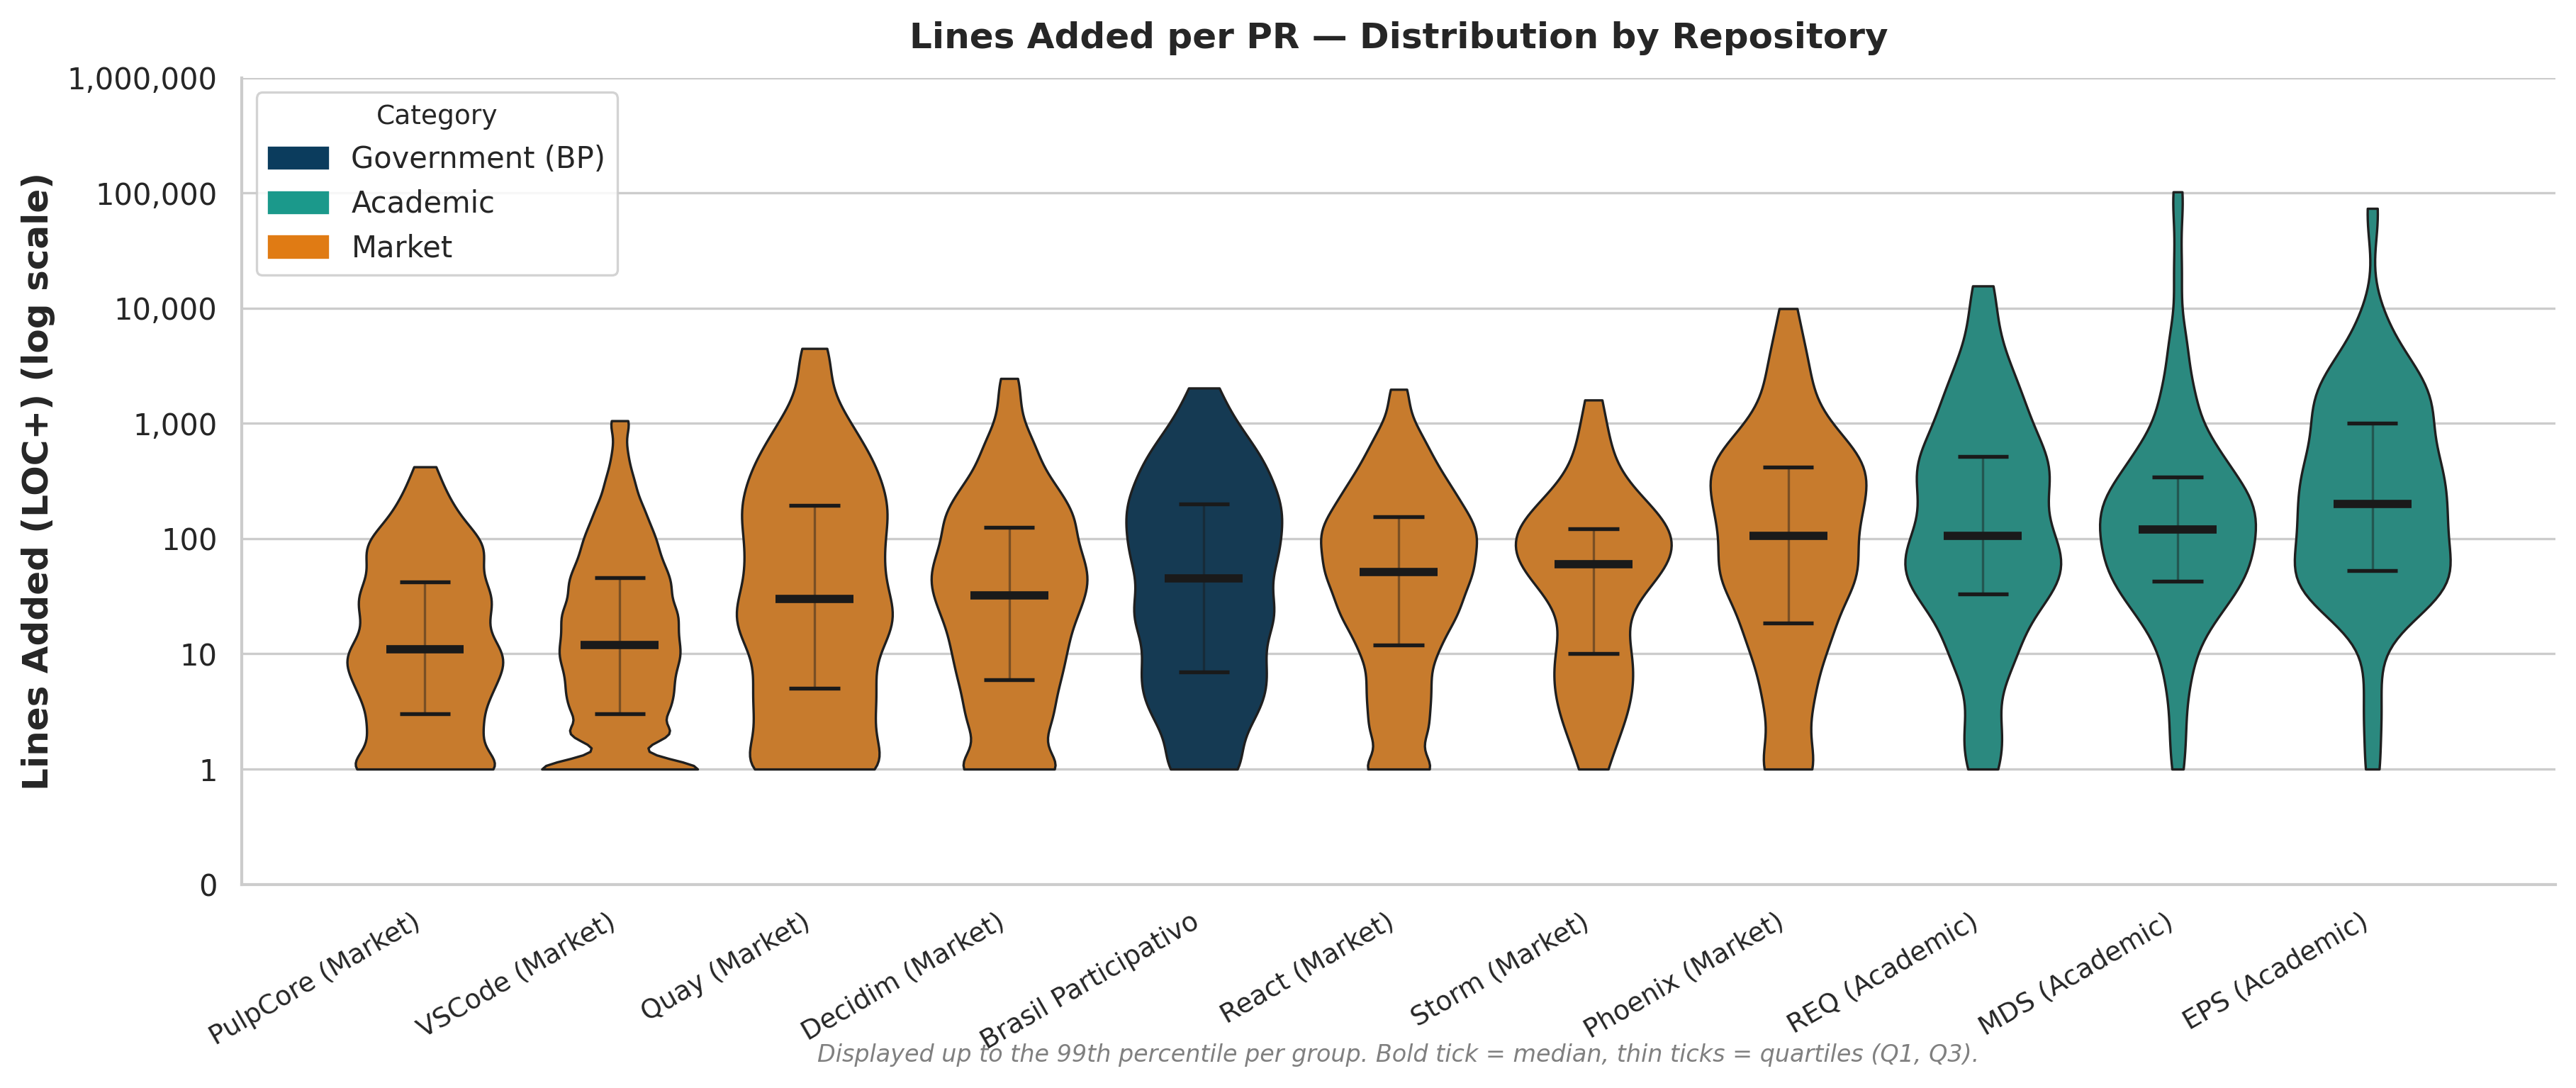

In [4]:
_ = plot_violin(
    groups,
    metric='additions',
    xlabel='Lines Added (LOC+)',
    title='Lines Added per PR — Distribution by Repository',
    log_scale=True,
    clip_pct=99,
    min_value=0,
    save_path=FIGURES_DIR / 'violin_loc_added.pdf',
)

Saved: figures/violin_loc_removed.pdf


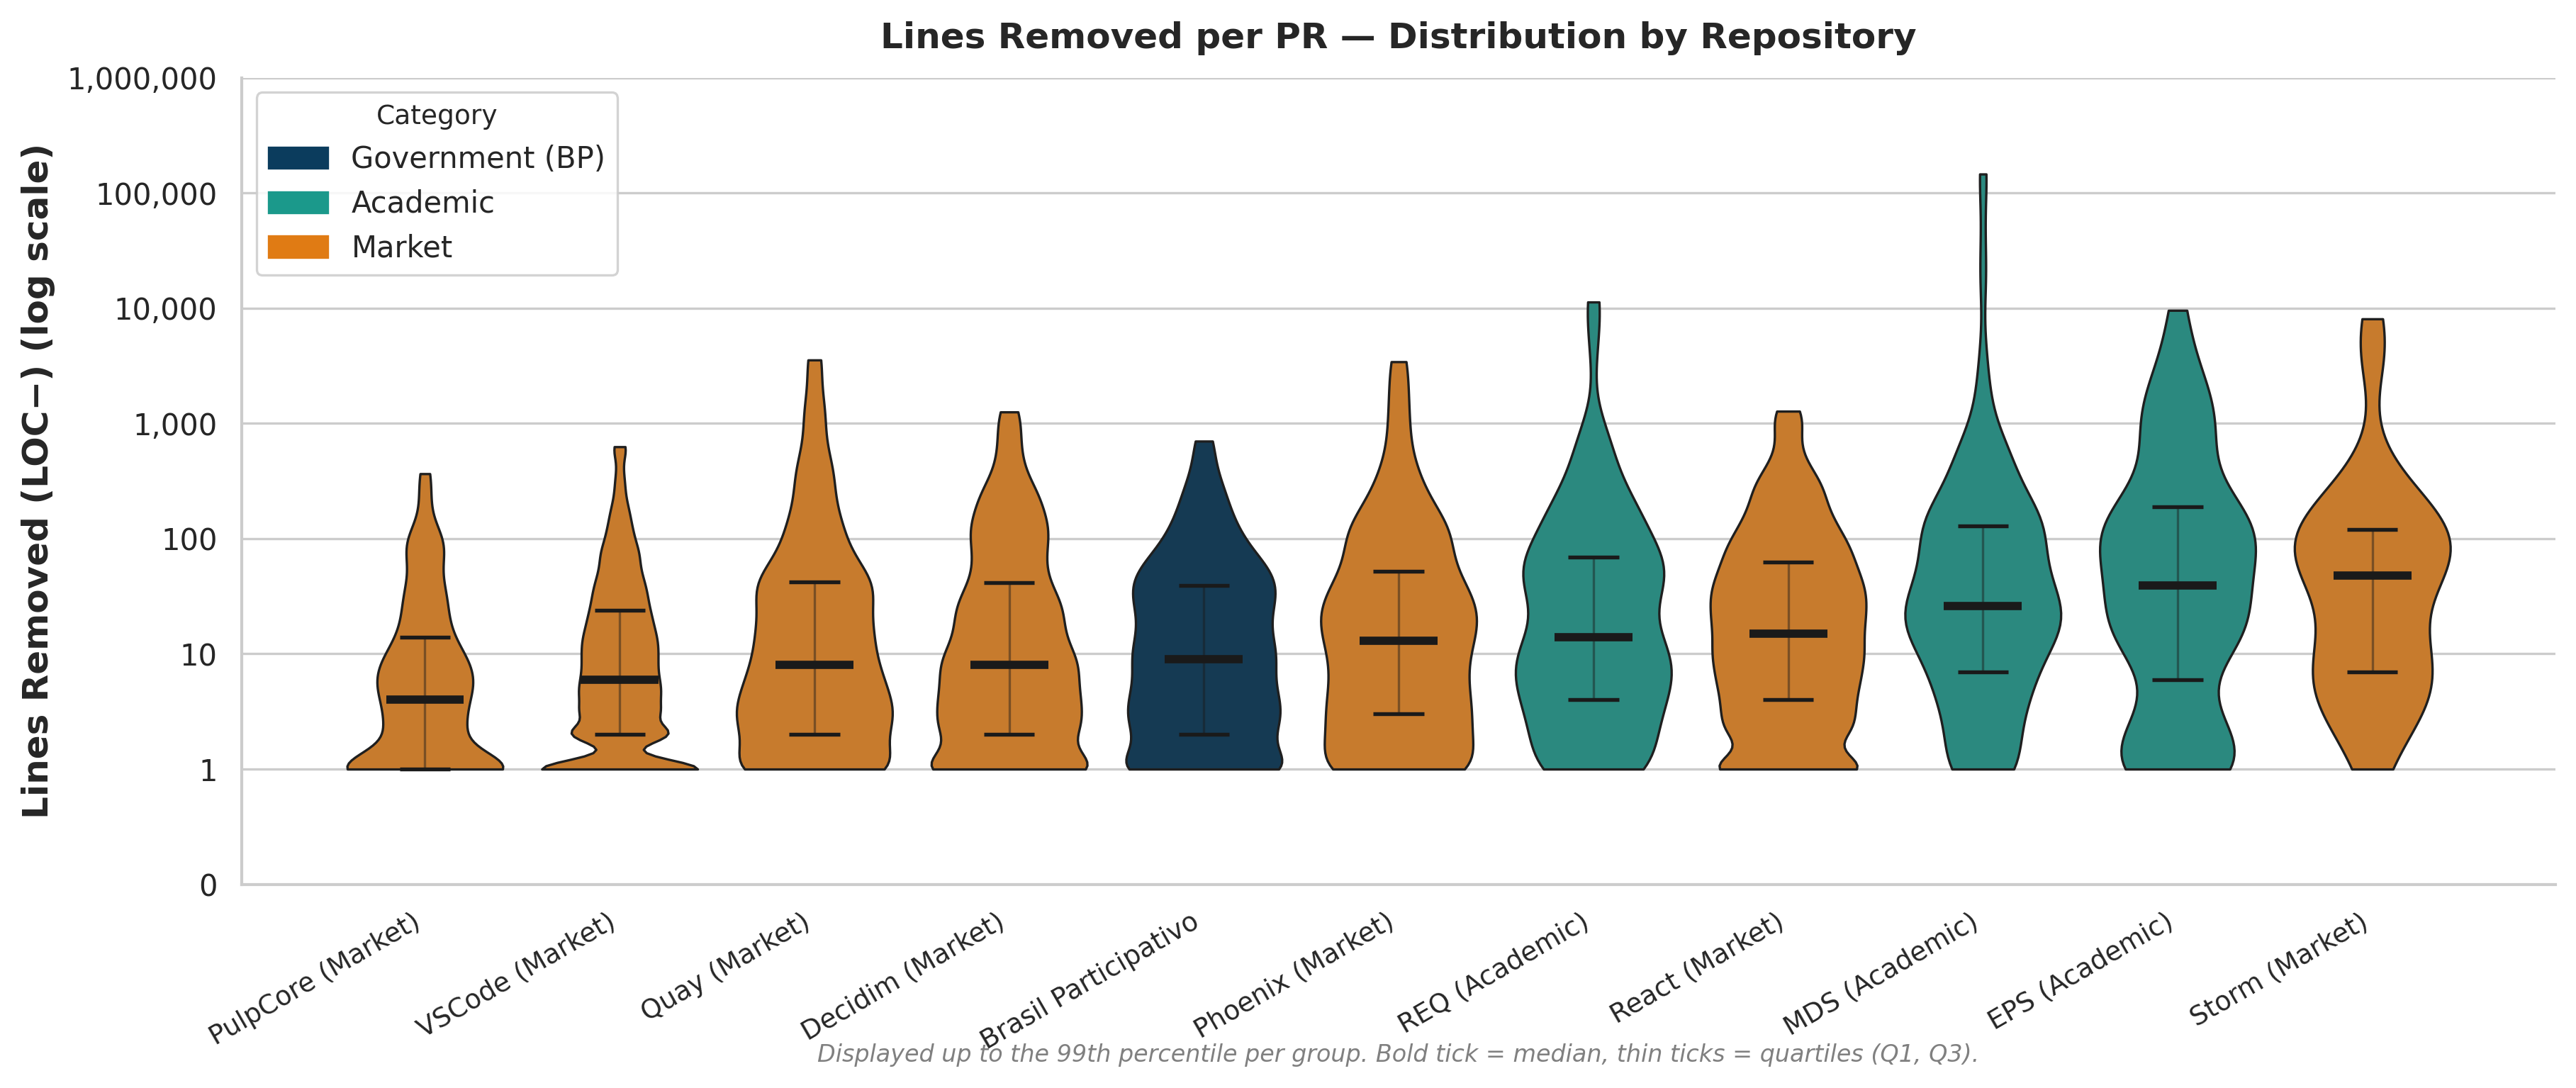

In [5]:
_ = plot_violin(
    groups,
    metric='deletions',
    xlabel='Lines Removed (LOC−)',
    title='Lines Removed per PR — Distribution by Repository',
    log_scale=True,
    clip_pct=99,
    min_value=0,
    save_path=FIGURES_DIR / 'violin_loc_removed.pdf',
)

Saved: figures/violin_churn.pdf


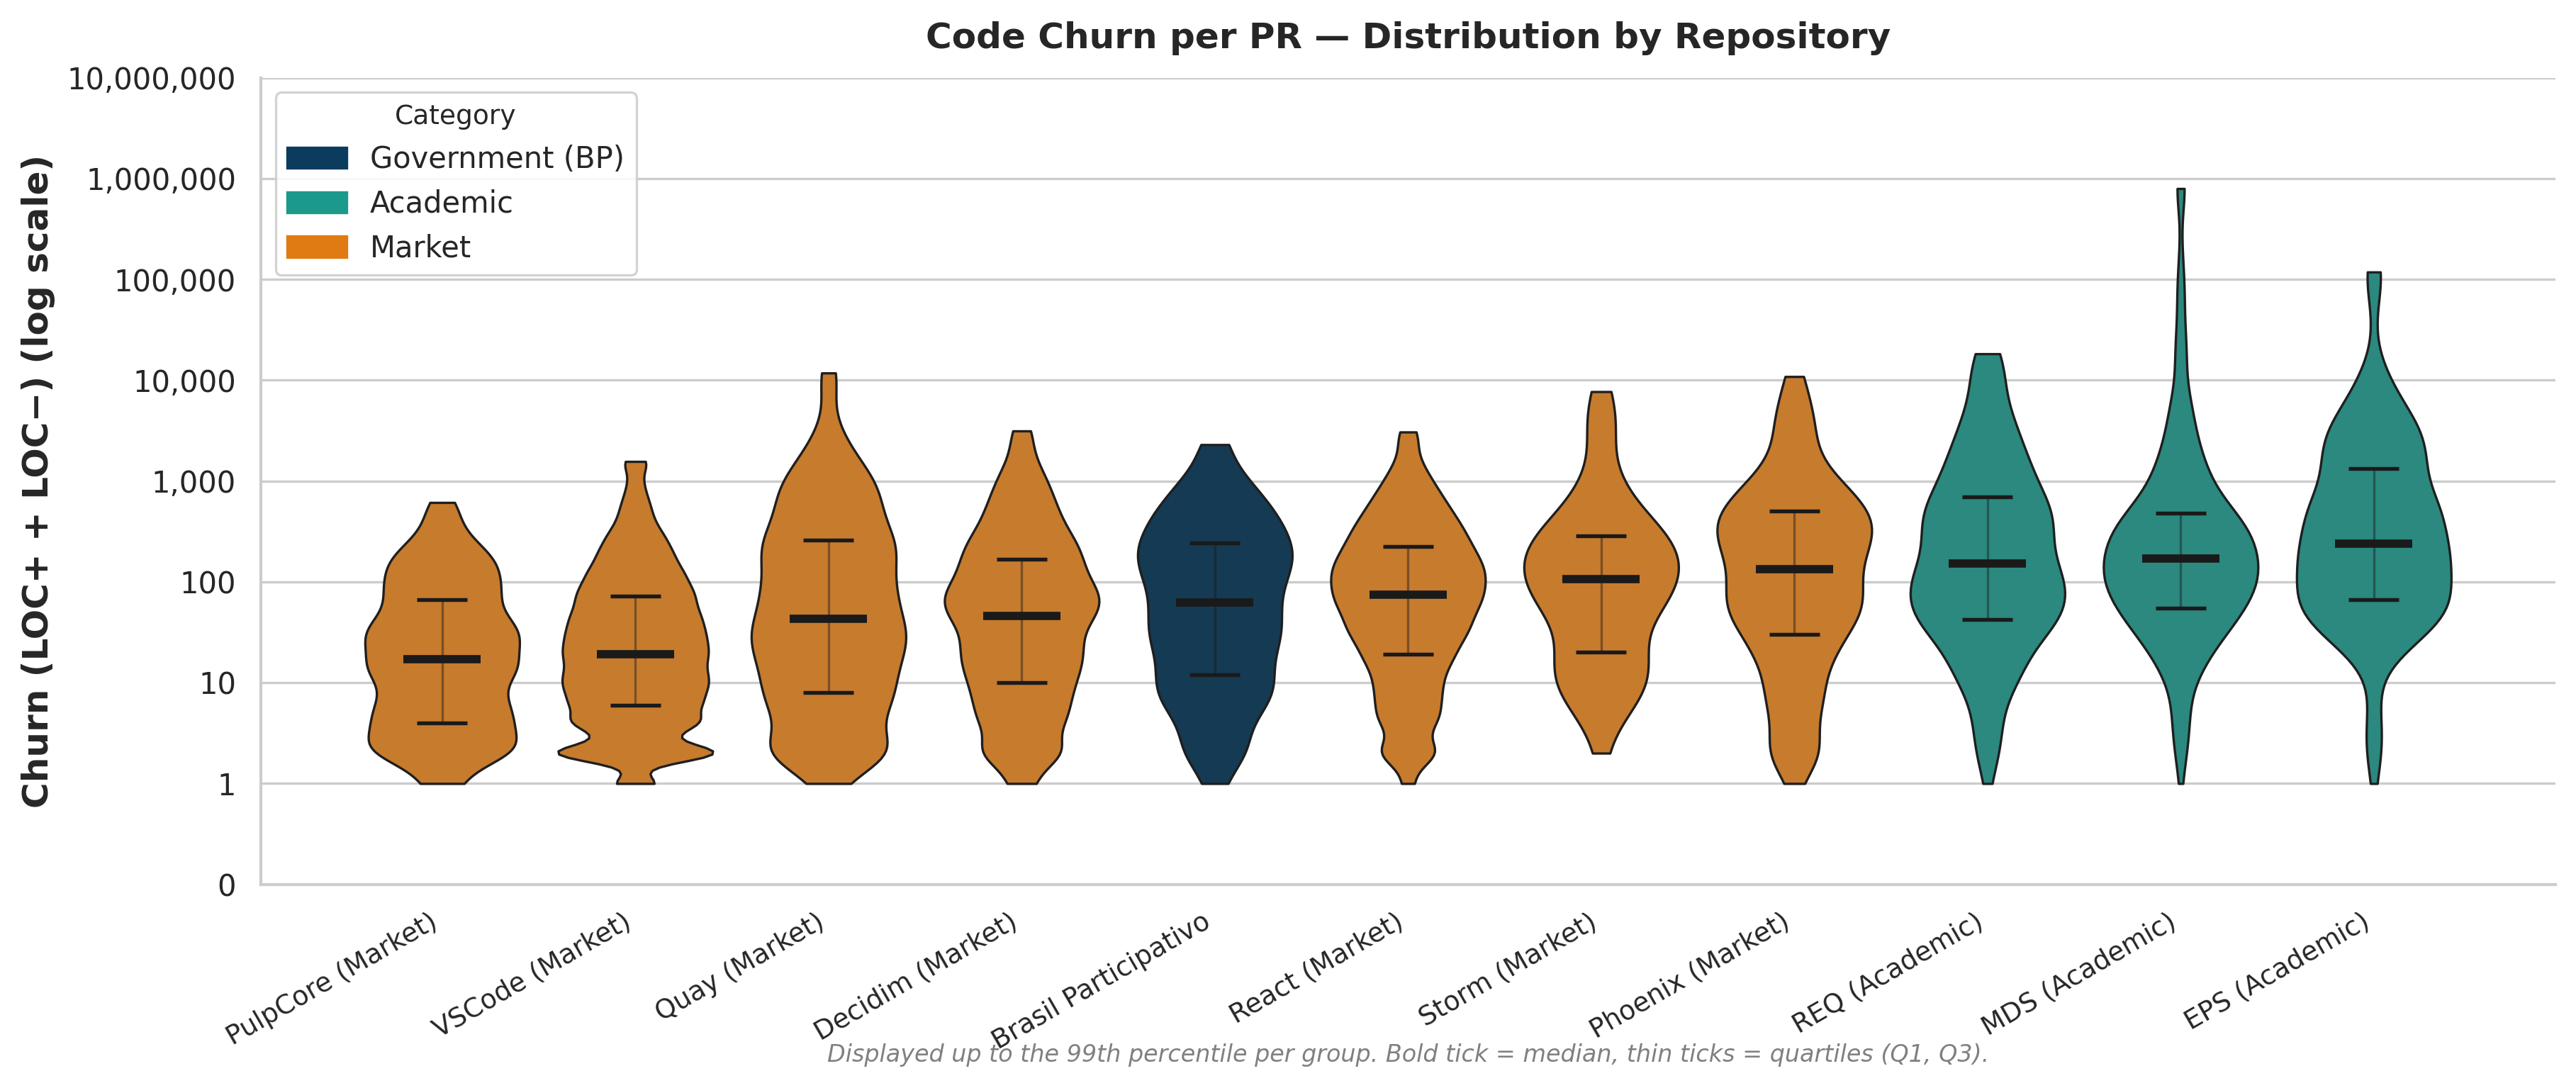

In [6]:
_ = plot_violin(
    groups,
    metric='churn',
    xlabel='Churn (LOC+ + LOC−)',
    title='Code Churn per PR — Distribution by Repository',
    log_scale=True,
    clip_pct=99,
    min_value=0,
    save_path=FIGURES_DIR / 'violin_churn.pdf',
)

Saved: figures/violin_files_changed.pdf


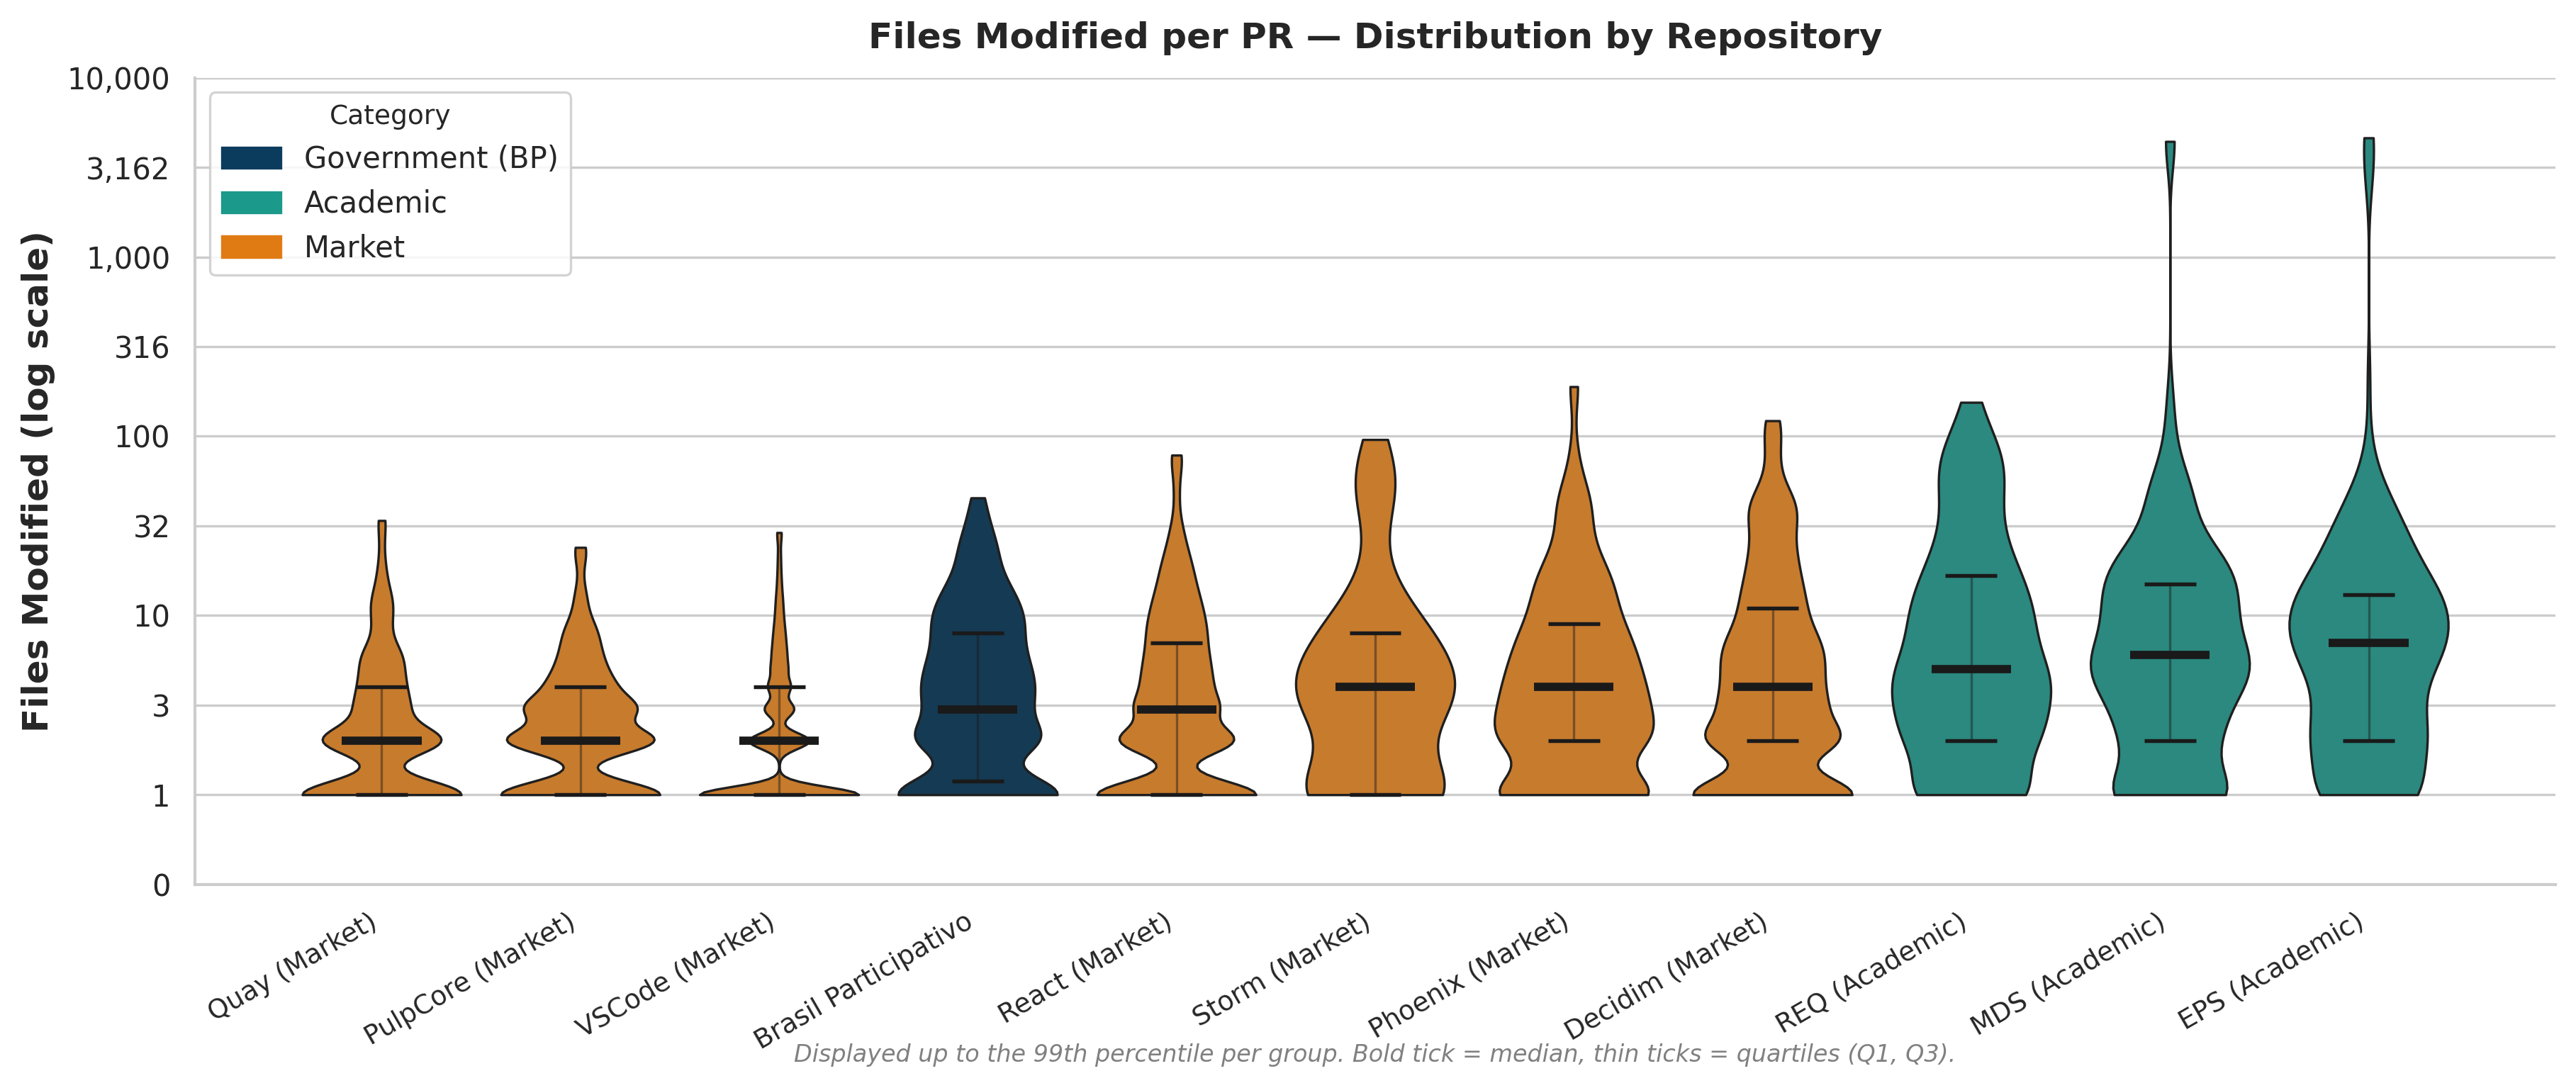

In [7]:
_ = plot_violin(
    groups,
    metric='files_changed',
    xlabel='Files Modified',
    title='Files Modified per PR — Distribution by Repository',
    log_scale=True,
    clip_pct=99,
    min_value=0,
    save_path=FIGURES_DIR / 'violin_files_changed.pdf',
)

In [8]:
# ── Descriptive statistics table for LOC / Files ──────────────────────────────
metrics_cfg = [
    ('additions',     'LOC Added'),
    ('deletions',     'LOC Removed'),
    ('churn',         'Churn'),
    ('files_changed', 'Files Changed'),
]

stat_rows = []
for metric, mlabel in metrics_cfg:
    for label, df in groups.items():
        vals = df[metric].dropna()
        vals = vals[vals > 0]
        stat_rows.append({
            'Metric':  mlabel,
            'Group':   label,
            'n':       len(vals),
            'Median':  round(vals.median(), 1),
            'IQR':     round(vals.quantile(0.75) - vals.quantile(0.25), 1),
            'P90':     round(vals.quantile(0.90), 1),
            'P99':     round(vals.quantile(0.99), 1),
        })

stats_df = pd.DataFrame(stat_rows)
display(stats_df.set_index(['Metric', 'Group']))

n  Median     IQR     P90       P99
Metric        Group                                                        
LOC Added     Brasil Participativo    500    45.0   192.0   536.9    2026.8
              MDS (Academic)          343   120.0   300.5  1513.2  102109.9
              REQ (Academic)          225   106.0   487.0  2183.0   15588.5
              EPS (Academic)          224   200.0   950.0  2829.5   73424.5
              Decidim (Market)       1515    32.0   120.0   342.0    2453.4
              VSCode (Market)       14556    12.0    43.0   142.0    1054.5
              React (Market)         2500    51.0   144.0   404.1    1974.5
              Storm (Market)           51    60.0   111.5   240.0    1596.0
              Phoenix (Market)        346   105.5   400.5  1172.0    9910.6
              PulpCore (Market)       669    11.0    39.0   106.0     419.8
              Quay (Market)           737    30.0   189.0   625.8    4469.4
LOC Removed   Brasil Participativo    457     9.0    37.0   110.0     701.4
              MDS (Academic)          289    26.0   121.0   443.6  145869.3
              REQ (Academic)          201    14.0    65.0   210.0   11306.0
              EPS (Academic)          201    39.0   182.0  1168.0    9573.0
              Decidim (Market)       1378     8.0    39.8   197.6    1257.2
              VSCode (Market)       13596     6.0    22.0    78.0     627.2
              React (Market)         2295    15.0    59.0   207.2    1276.0
              Storm (Market)           47    48.0   113.5   290.2    8076.5
              Phoenix (Market)        323    13.0    49.0   187.8    3428.6
              PulpCore (Market)       605     4.0    13.0    65.2     366.0
              Quay (Market)           662     8.0    40.0   209.6    3551.6
Churn         Brasil Participativo    511    62.0   231.0   616.0    2295.4
              MDS (Academic)          343   169.0   422.5  2519.2  795447.5
              REQ (Academic)          230   151.0   657.0  3059.6   18281.3
              EPS (Academic)          225   240.0  1257.0  4442.8  118283.5
              Decidim (Market)       1549    46.0   158.0   554.2    3138.8
              VSCode (Market)       14915    19.0    66.0   217.0    1562.8
              React (Market)         2586    74.0   205.8   592.0    3062.1
              Storm (Market)           53   106.0   268.0   836.4    7698.1
              Phoenix (Market)        350   133.0   476.0  1354.0   10867.2
              PulpCore (Market)       685    17.0    63.0   176.2     612.2
              Quay (Market)           763    43.0   249.5   900.0   11789.9
Files Changed Brasil Participativo    510     3.0     6.8    15.0      45.3
              MDS (Academic)          347     6.0    13.0    33.0    4409.3
              REQ (Academic)          230     5.0    14.8    56.0     154.5
              EPS (Academic)          227     7.0    11.0    29.4    4618.0
              Decidim (Market)       1552     4.0     9.0    32.0     122.0
              VSCode (Market)       14945     2.0     3.0     8.0      29.0
              React (Market)         2587     3.0     6.0    16.0      78.4
              Storm (Market)           53     4.0     7.0    29.8      95.8
              Phoenix (Market)        350     4.0     7.0    21.0     189.0
              PulpCore (Market)       685     2.0     3.0     7.0      24.0
              Quay (Market)           764     2.0     3.0     8.0      33.9

---
## 2  Refactoring

### Design rationale

O **refactoring ratio** é definido como `deletions / churn`, capturando a proporção do trabalho
de uma PR que representa remoção (ou substituição) de código existente em vez de adição pura.
Valores próximos de 0 indicam PRs predominantemente aditivas; valores próximos de 1 indicam
que a maior parte do esforço foi na remoção/reescrita.

A versão conferência apresentava um histograma do BP com linhas de mediana sobrepostas,
impedindo a comparação da forma da distribuição entre grupos. Aqui substituímos por violin plots
que permitem responder:

- Quais repositórios têm comportamento mais consistente (violinos estreitos)?
- Quais apresentam maior variabilidade (violinos largos)?
- Há repositórios com distribuição bimodal (dois "balões")?

Como o ratio está na escala [0, 1], não é necessária transformação logarítmica.
PRs com `churn == 0` são excluídas (razão indefinida).

Saved: figures/violin_refactoring_ratio.pdf


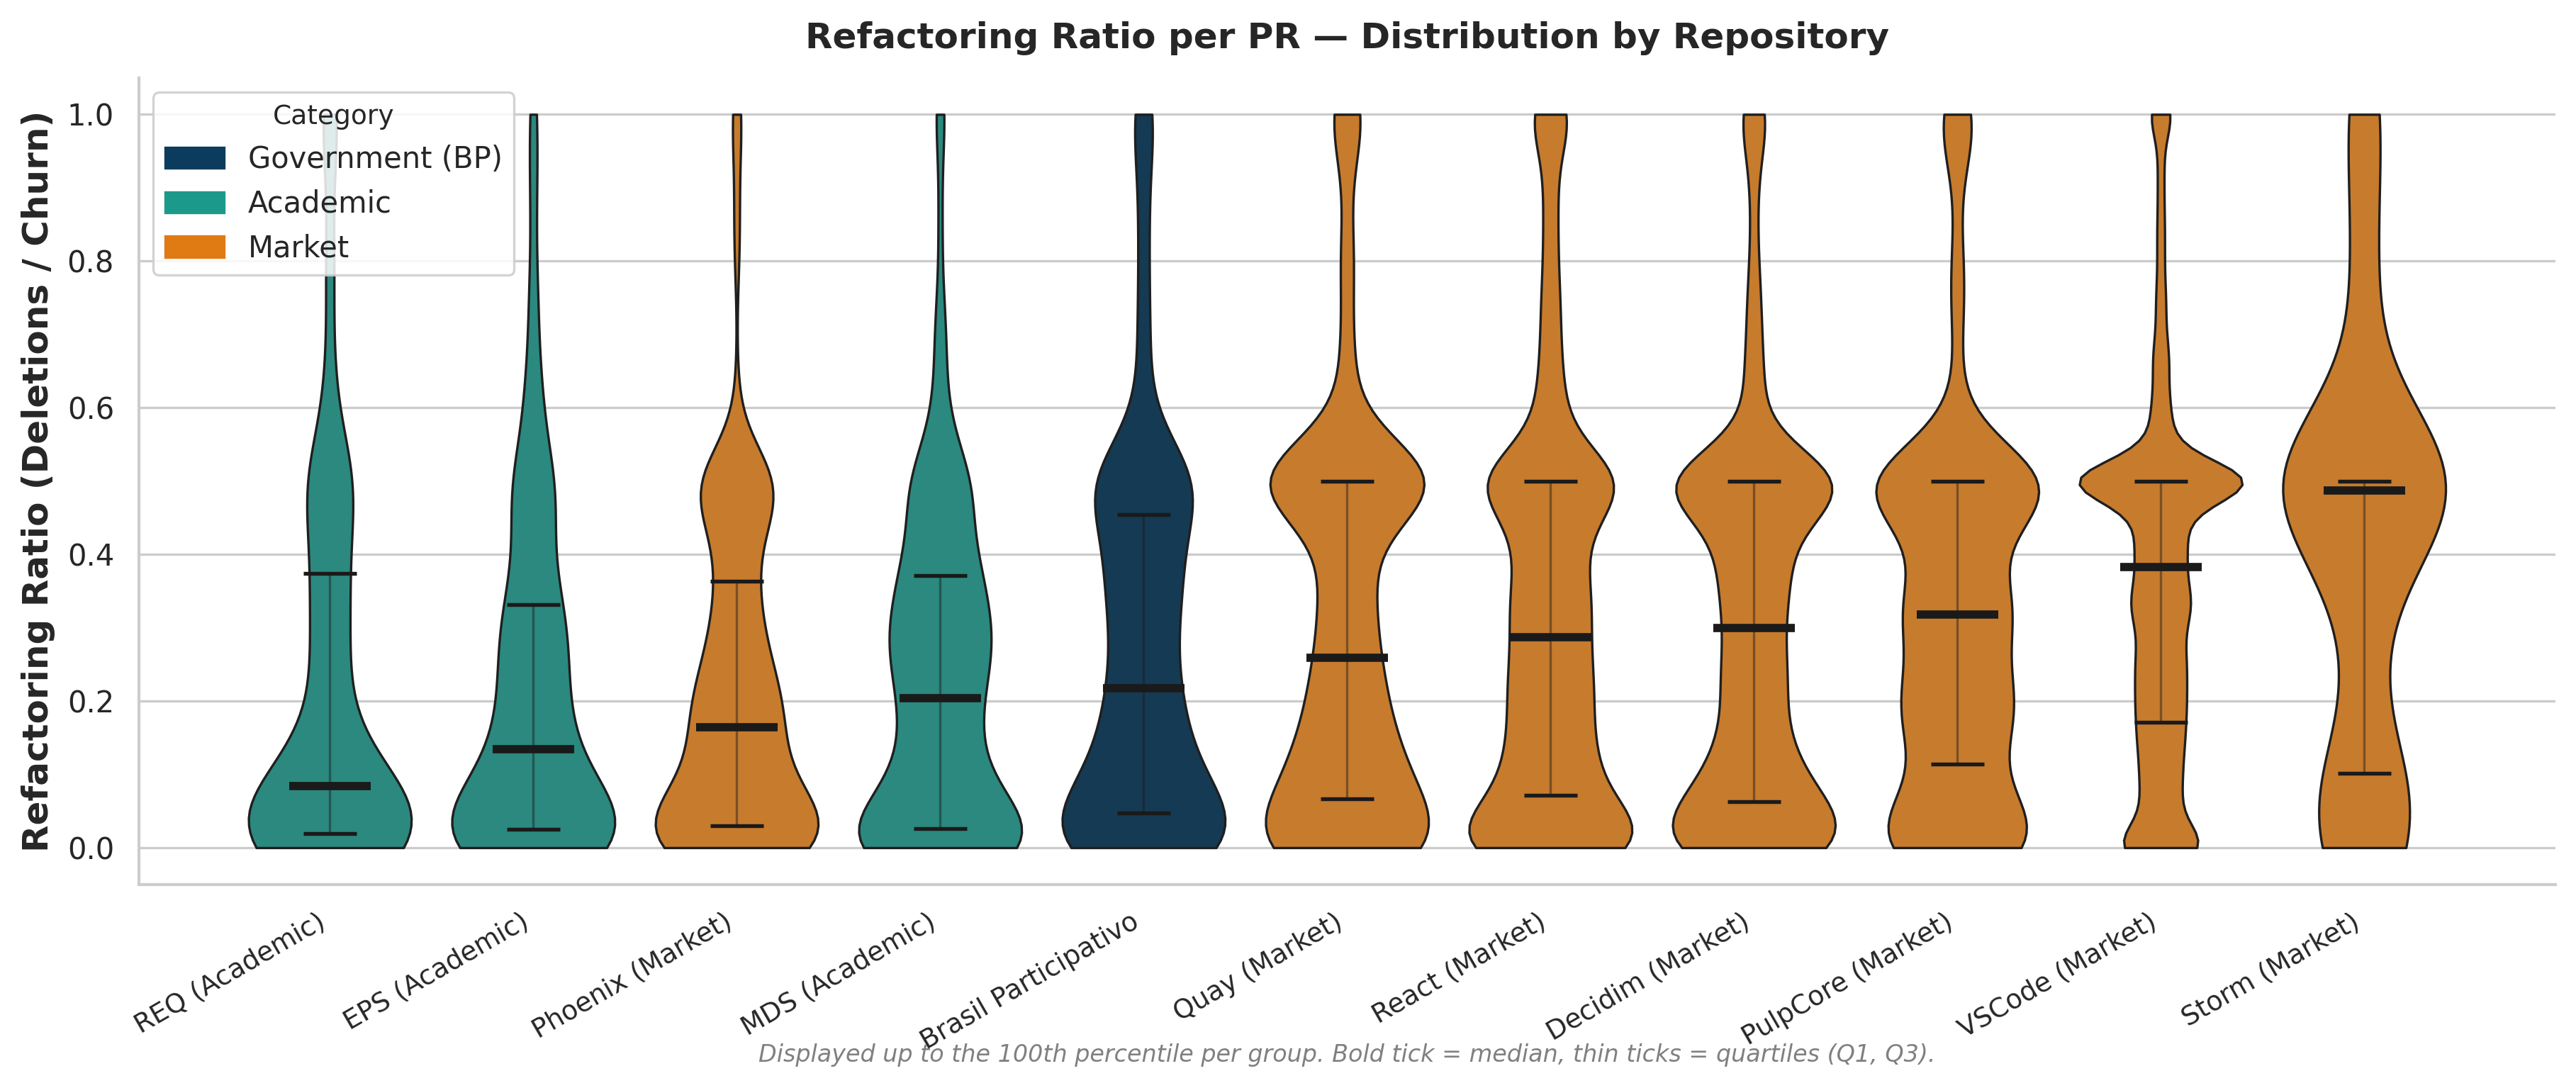

In [9]:
# Compute refactoring ratio per group and add to a copy
groups_ref: dict[str, pd.DataFrame] = {}
for label, df in groups.items():
    tmp = df[df['churn'] > 0].copy()
    tmp['refactor_ratio'] = tmp['deletions'] / tmp['churn']
    groups_ref[label] = tmp

_ = plot_violin(
    groups_ref,
    metric='refactor_ratio',
    xlabel='Refactoring Ratio (Deletions / Churn)',
    title='Refactoring Ratio per PR — Distribution by Repository',
    log_scale=False,   # ratio in [0,1]: no log needed
    clip_pct=100,      # no clipping: the metric is bounded
    min_value=-0.001,  # include 0
    save_path=FIGURES_DIR / 'violin_refactoring_ratio.pdf',
)

In [10]:
# Descriptive stats for refactoring ratio
ref_rows = []
for label, df in groups_ref.items():
    vals = df['refactor_ratio']
    ref_rows.append({
        'Group':   label,
        'n':       len(vals),
        'Median':  round(vals.median(), 3),
        'Mean':    round(vals.mean(),   3),
        'Std':     round(vals.std(),    3),
        'P25':     round(vals.quantile(0.25), 3),
        'P75':     round(vals.quantile(0.75), 3),
    })

display(pd.DataFrame(ref_rows).set_index('Group'))

,n,Median,Mean,Std,P25,P75
Group,,,,,,
Brasil Participativo,511,0.217,0.277,0.257,0.048,0.455
MDS (Academic),343,0.204,0.234,0.220,0.026,0.371
REQ (Academic),230,0.084,0.219,0.264,0.020,0.374
EPS (Academic),225,0.134,0.215,0.232,0.025,0.332
Decidim (Market),1549,0.300,0.309,0.257,0.062,0.500
VSCode (Market),14915,0.382,0.364,0.240,0.171,0.500
React (Market),2586,0.287,0.321,0.273,0.071,0.500
Storm (Market),53,0.487,0.412,0.287,0.102,0.500
Phoenix (Market),350,0.164,0.219,0.221,0.030,0.364


---
## 3  Pace — PR Activity Heatmap

### Design rationale

O heatmap de atividade (dia da semana × bloco de 2 horas) é mantido da versão conferência
porque é o método mais eficiente para revelar padrões temporais bidimensionais em dados
de séries de eventos. Nenhum gráfico alternativo (e.g., histograma de horas, gráfico de linha
por dia) captura simultaneamente a dimensão dia-hora sem perda de informação.

**Melhorias implementadas:**
- Anotações numéricas com contraste automático (branco sobre escuro, preto sobre claro).
- Contorno destacando o período de horário comercial (08h–18h, seg–sex) com cor constrastante.
- Repositórios exibidos individualmente (BP, Academic combinado, e os principais de Market).
- Colormap normalizado por total de PRs para permitir comparação entre grupos de tamanhos diferentes.

In [11]:
from matplotlib.patches import Rectangle


def prepare_timestamps(df: pd.DataFrame, tz: str = 'America/Sao_Paulo') -> pd.DataFrame:
    out = df.copy()
    for col in ('created_at', 'merged_at'):
        out[col] = pd.to_datetime(out[col], utc=True, errors='coerce')
        try:
            out[f'{col}_local'] = out[col].dt.tz_convert(tz)
        except Exception:
            out[f'{col}_local'] = out[col]
    return out


def build_heatmap_matrix(df: pd.DataFrame, normalize: bool = False) -> pd.DataFrame:
    """Aggregate PR created + merged events into a day-of-week × 2h-block matrix."""
    events = []
    for col in ('created_at_local', 'merged_at_local'):
        tmp = df[col].dropna()
        events.append(pd.DataFrame({'day': tmp.dt.day_name(), 'hour': tmp.dt.hour}))
    combined = pd.concat(events)

    pivot = combined.groupby(['day', 'hour']).size().unstack(fill_value=0)

    days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    pivot = pivot.reindex(days, fill_value=0)
    for h in range(24):
        if h not in pivot.columns:
            pivot[h] = 0
    pivot = pivot[sorted(pivot.columns)]
    pivot.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

    # Bin into 2-hour blocks
    pivot_binned = pivot.T.groupby(np.arange(len(pivot.columns)) // 2).sum().T
    pivot_binned.columns = [f'{h:02d}h' for h in range(0, 24, 2)]

    if normalize:
        pivot_binned = pivot_binned / pivot_binned.values.sum()

    return pivot_binned


def _auto_fmt(val, vmax) -> str:
    if vmax < 10:
        return f'{val:.2f}'
    return f'{int(val)}'


def plot_heatmap(
    df: pd.DataFrame,
    title: str,
    cmap_color: str = BP_PRIMARY,
    normalize: bool = False,
    highlight_business: bool = True,
    figsize: tuple = (8, 4),
    save_path: Path | None = None,
) -> plt.Figure:
    """
    Plot a publication-ready pace heatmap.

    normalize : express cell values as fraction of total (for cross-group comparison)
    """
    prepared = prepare_timestamps(df)
    matrix   = build_heatmap_matrix(prepared, normalize=normalize)

    cmap = LinearSegmentedColormap.from_list('custom', ['#ffffff', cmap_color])
    vmax = matrix.values.max()

    fig, ax = plt.subplots(figsize=figsize)

    # Determine text color per cell for contrast
    threshold = vmax * 0.55
    # pandas >= 2.1: use .map(); older versions used .applymap()
    annot_data = matrix.map(lambda v: _auto_fmt(v, vmax))

    sns.heatmap(
        matrix,
        cmap=cmap,
        annot=annot_data,
        fmt='',
        linewidths=0.4,
        linecolor='#e8e8e8',
        ax=ax,
        cbar_kws={'label': 'Fraction of PRs' if normalize else 'Number of PRs', 'shrink': 0.8},
        annot_kws={'size': 7.5},
        vmin=0, vmax=vmax,
    )

    # Auto-contrast text colors
    for text_obj, val in zip(ax.texts, matrix.values.flatten()):
        text_obj.set_color('white' if val > threshold else '#333333')

    if highlight_business:
        # Business hours: 08h–18h (columns 4–8 in 2h bins), Mon–Fri (rows 0–4)
        rect = Rectangle(
            (4, 0), 5, 5,
            linewidth=2, edgecolor=MKT_PRIMARY,
            facecolor='none', linestyle='-', zorder=10,
        )
        ax.add_patch(rect)
        ax.text(4 + 2.5, 5.35, 'Business hours (08h–18h)', ha='center',
                fontsize=8, color=MKT_PRIMARY, style='italic')

    ax.set_title(title, fontweight='bold', pad=12)
    ax.set_ylabel('Day of Week', fontweight='bold')
    ax.set_xlabel('Hour Block (UTC-3)', fontweight='bold')
    plt.xticks(rotation=0, fontsize=8)

    if save_path:
        fig.savefig(save_path, bbox_inches='tight')
        print(f'Saved: {save_path}')

    plt.show()
    return fig

Saved: figures/pace_bp.pdf


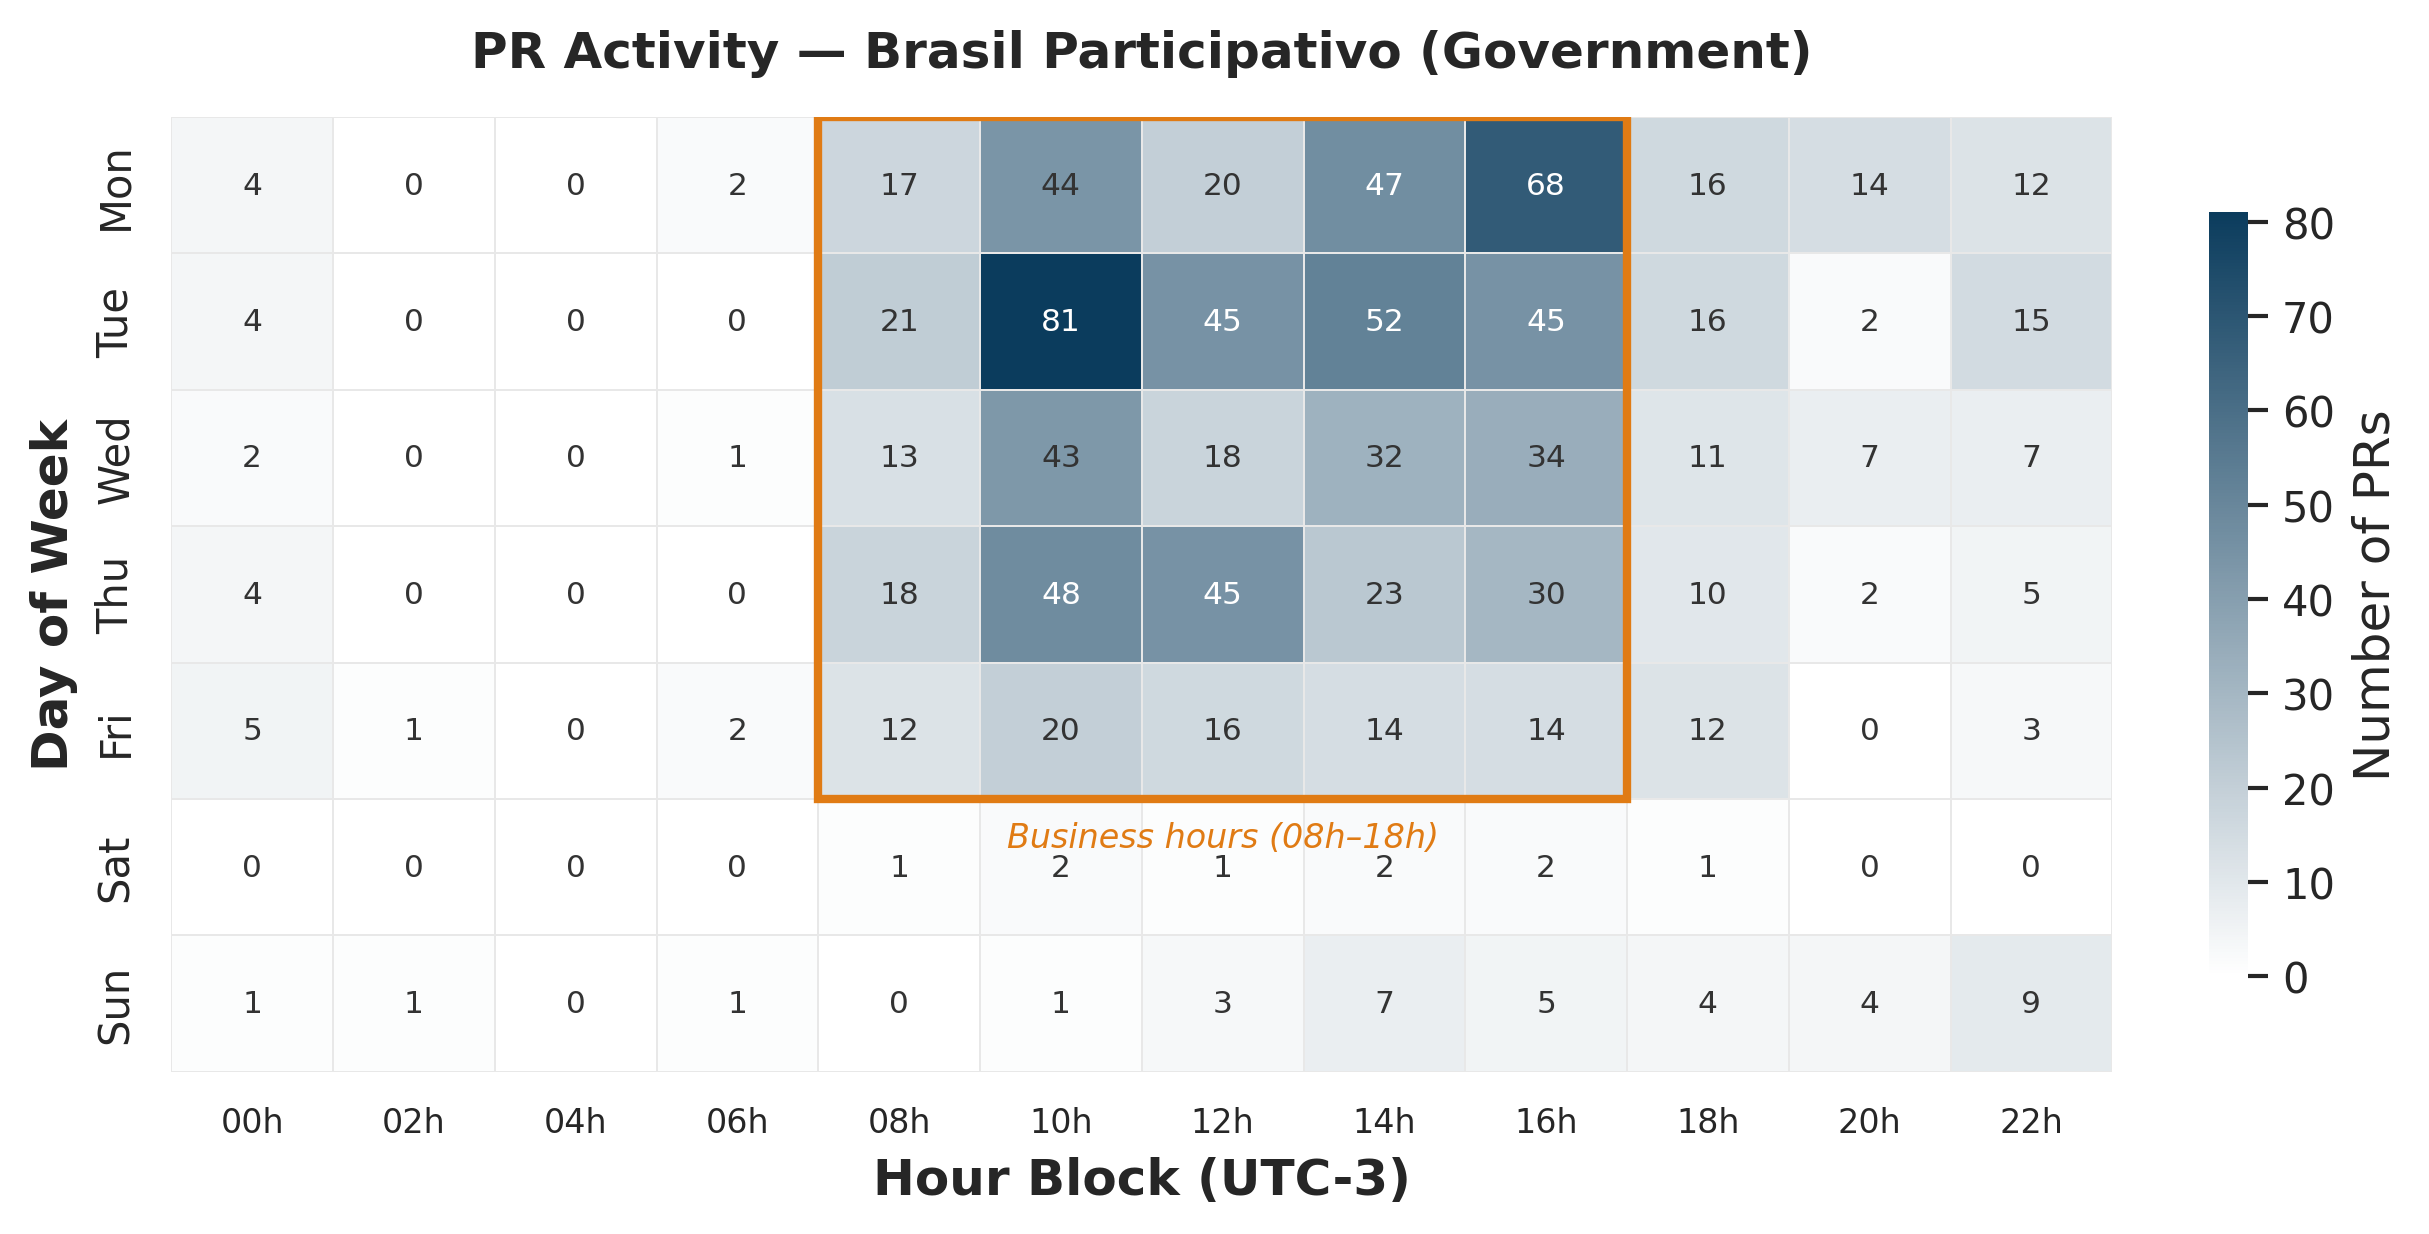

In [12]:
# Brasil Participativo
_ = plot_heatmap(
    groups['Brasil Participativo'],
    title='PR Activity — Brasil Participativo (Government)',
    cmap_color=BP_PRIMARY,
    normalize=False,
    save_path=FIGURES_DIR / 'pace_bp.pdf',
)

Saved: figures/pace_academic.pdf


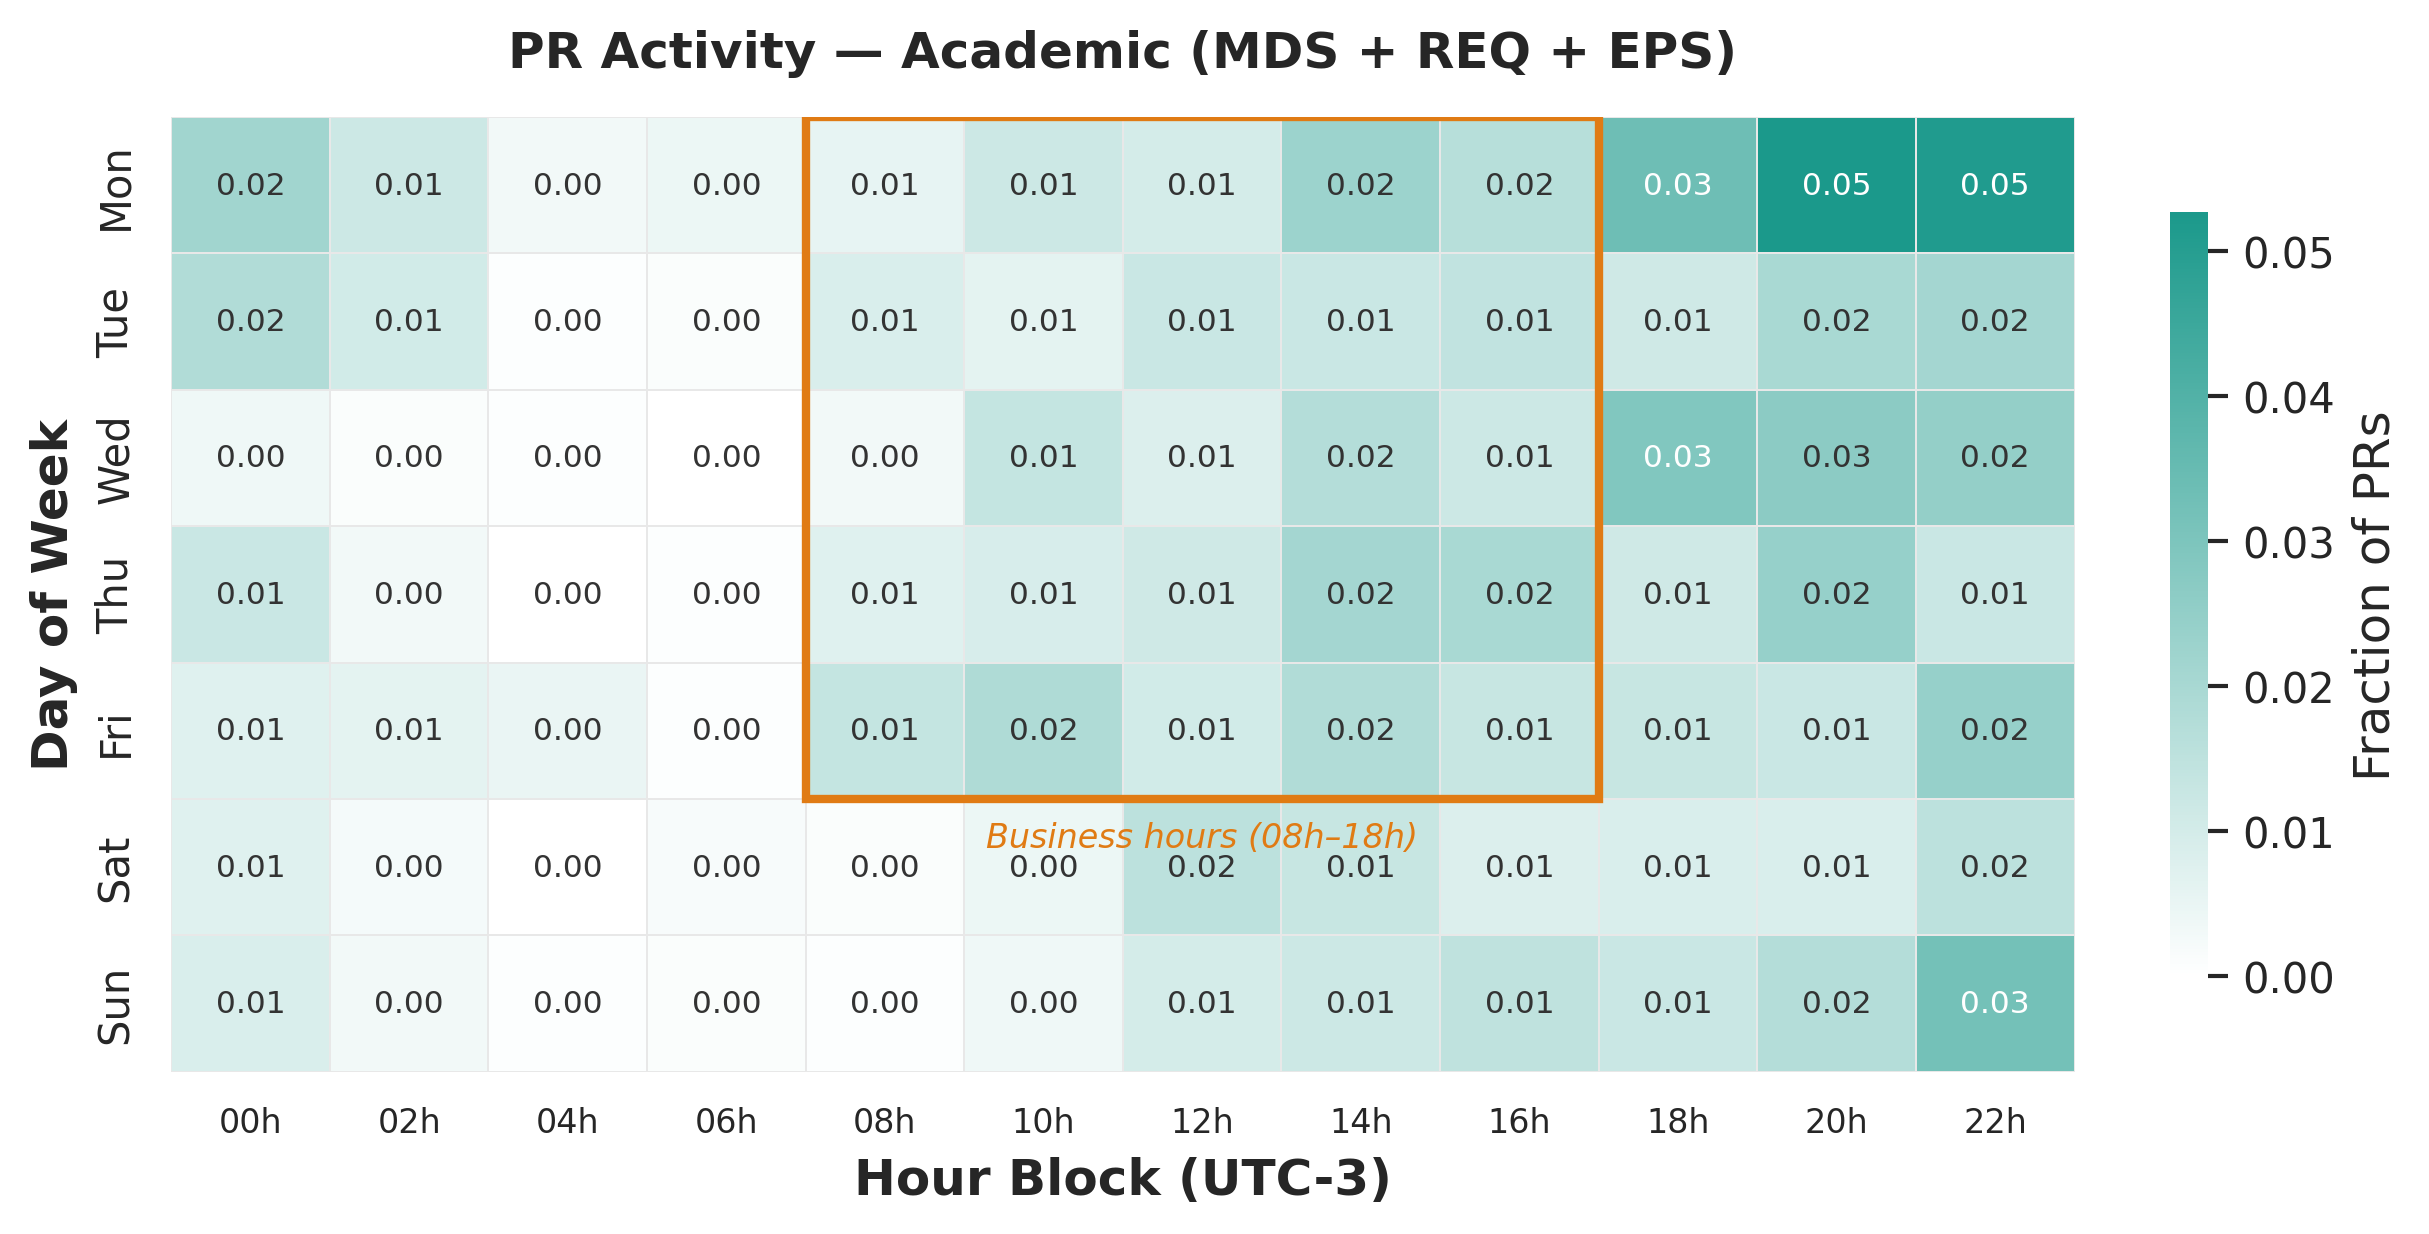

In [13]:
# All academic groups combined
df_academic = pd.concat([
    groups['MDS (Academic)'],
    groups['REQ (Academic)'],
    groups['EPS (Academic)'],
], ignore_index=True)

_ = plot_heatmap(
    df_academic,
    title='PR Activity — Academic (MDS + REQ + EPS)',
    cmap_color=ACAD_PRIMARY,
    normalize=True,  # normalize because group sizes differ
    save_path=FIGURES_DIR / 'pace_academic.pdf',
)

Saved: figures/pace_decidim_market.pdf


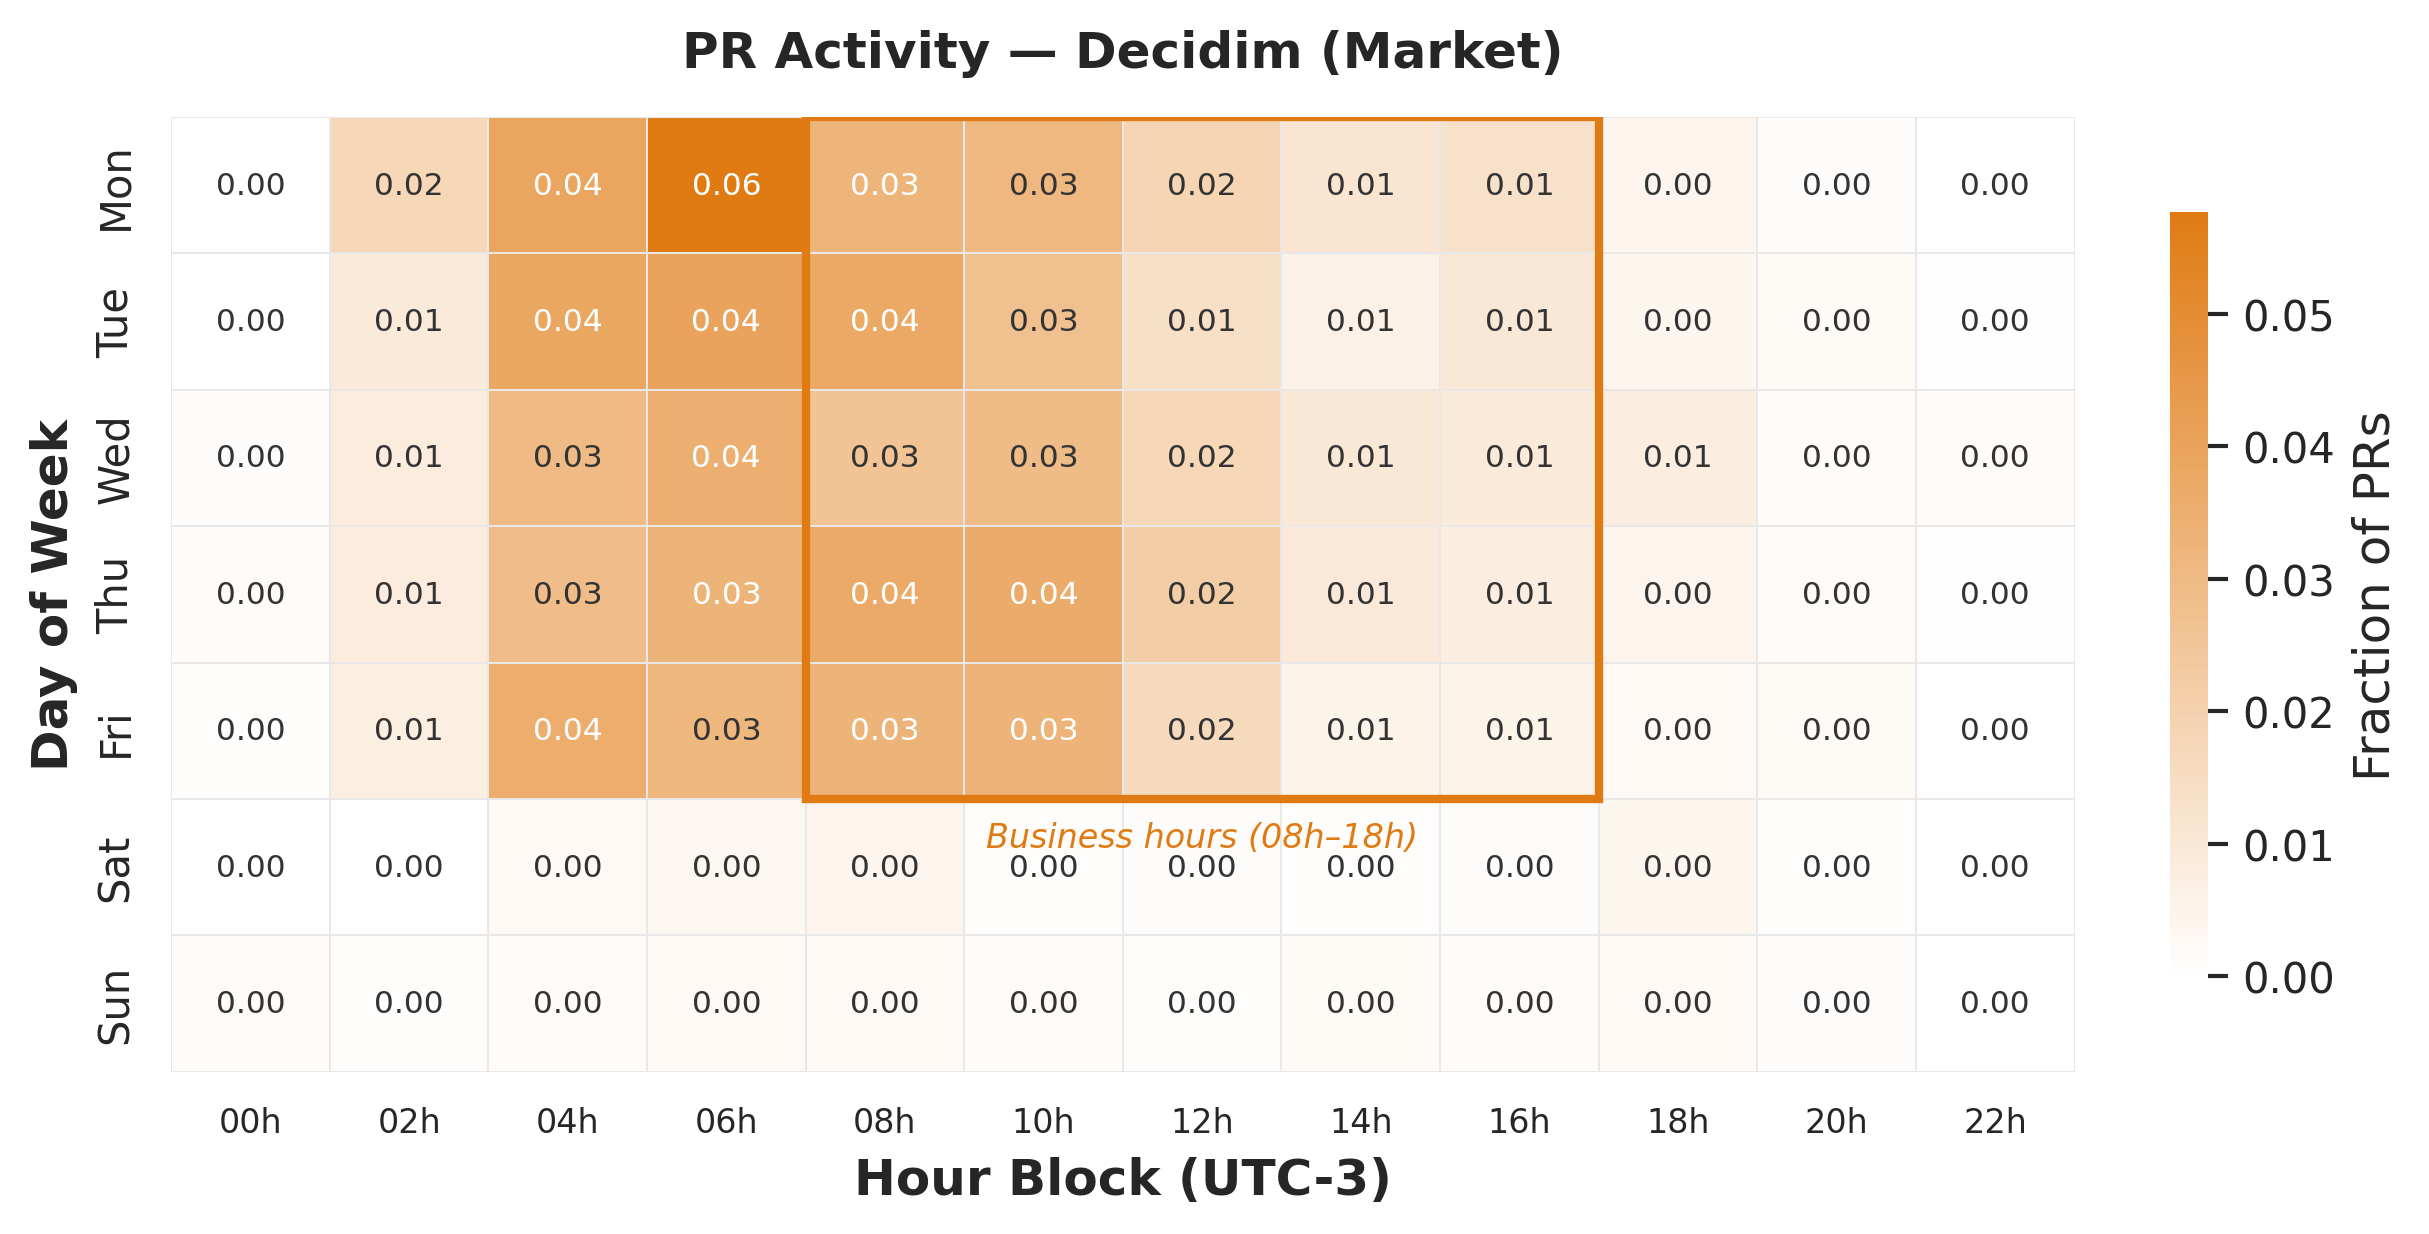

Saved: figures/pace_vscode_market.pdf


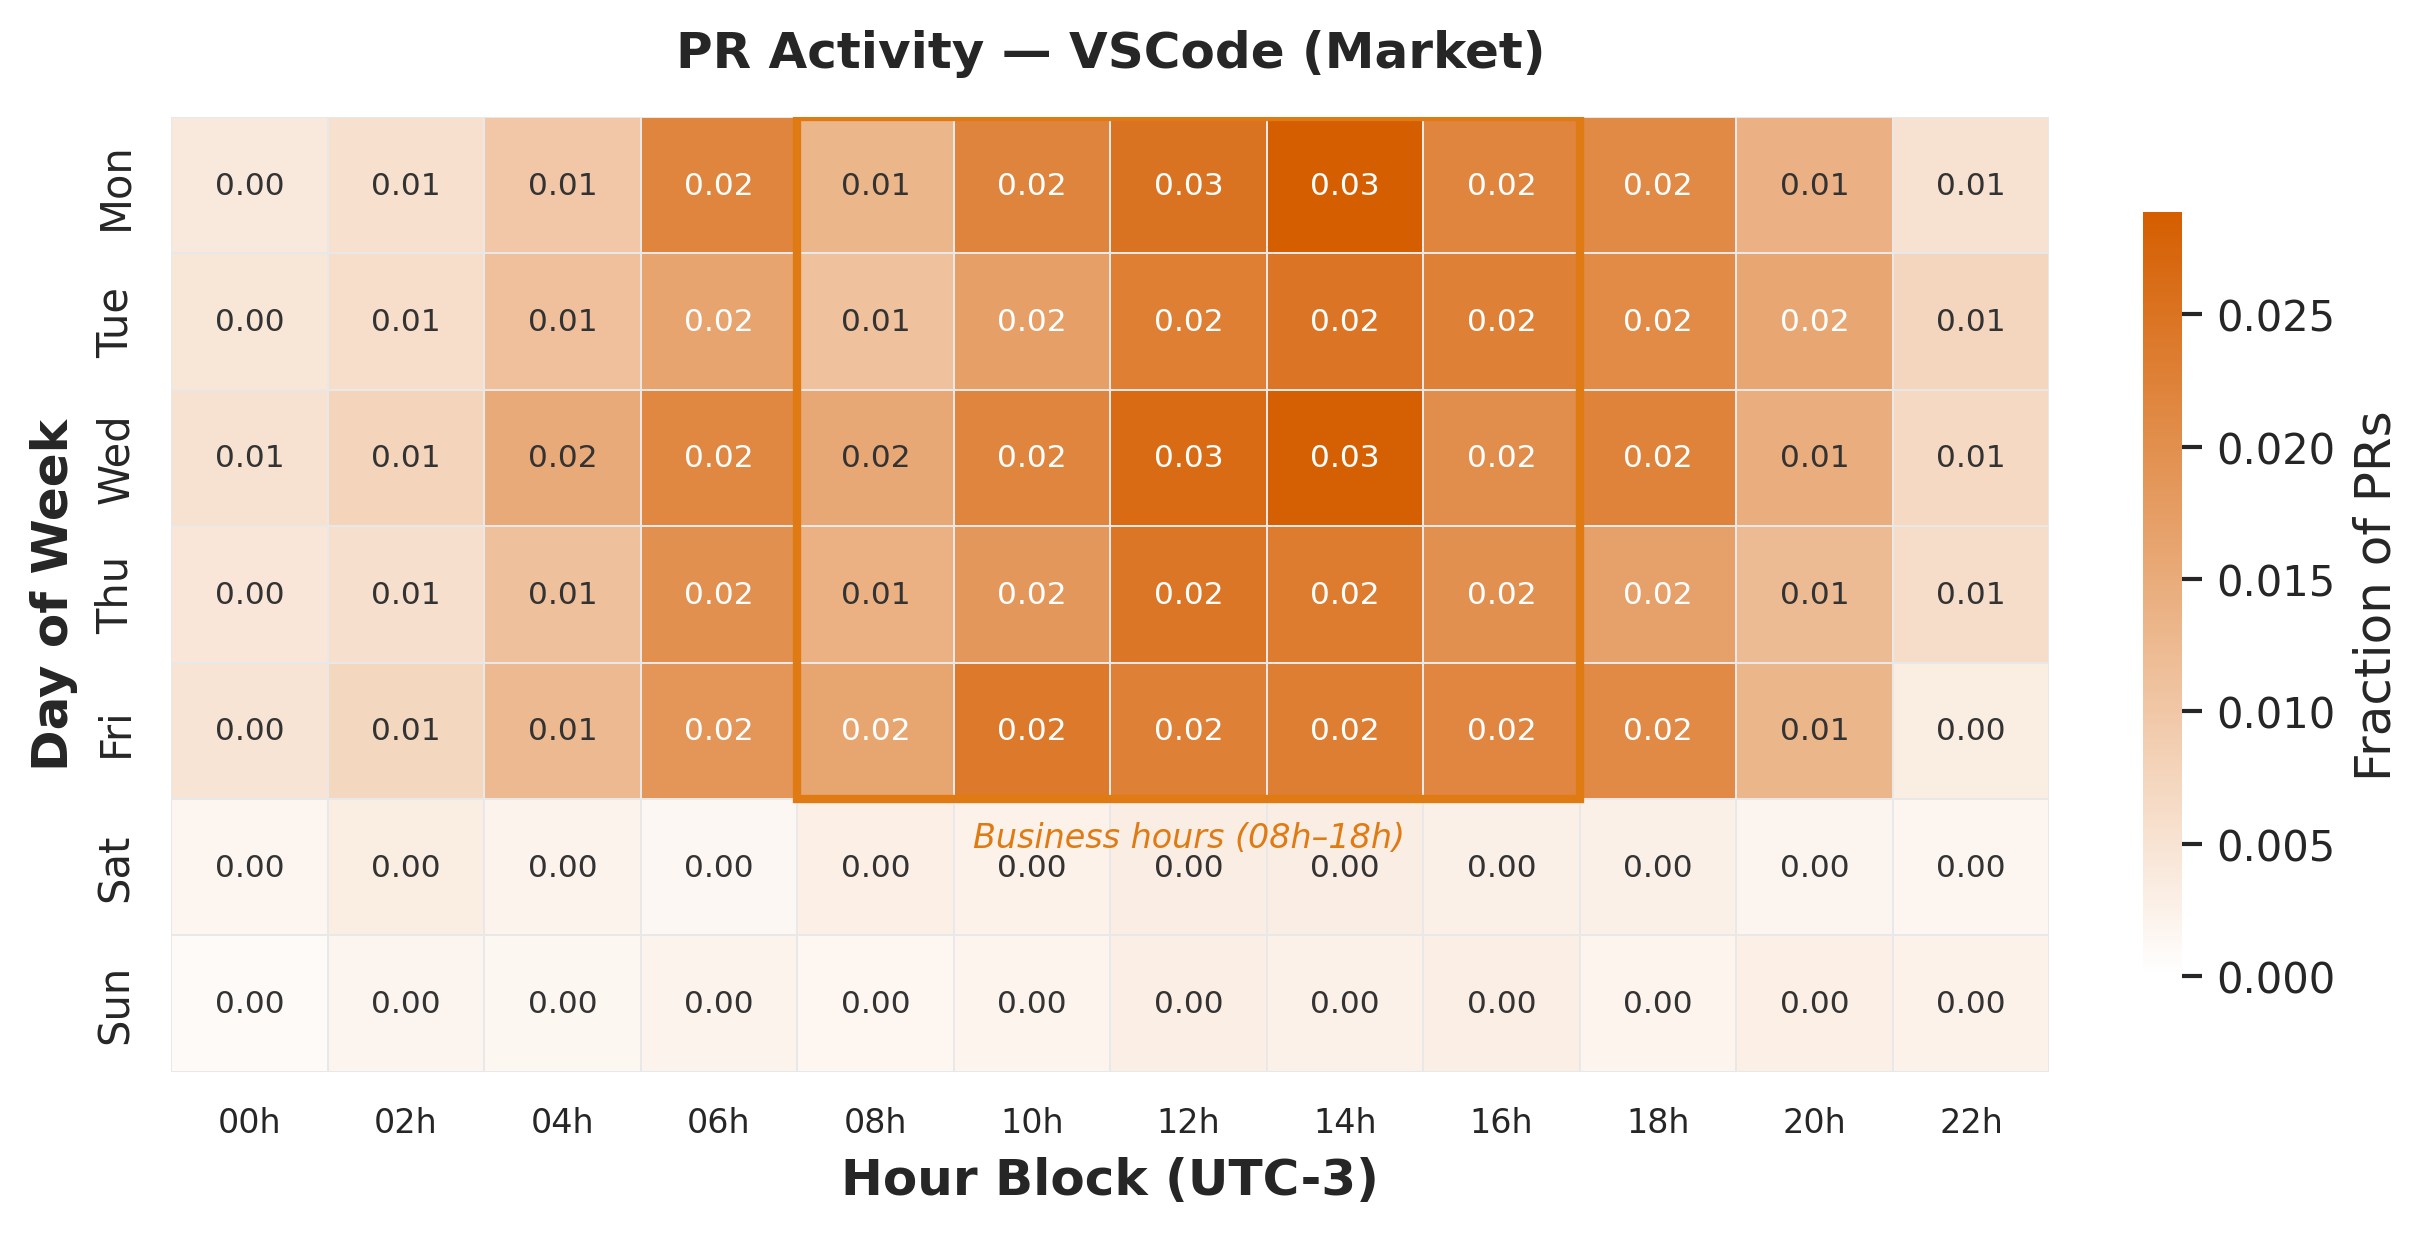

Saved: figures/pace_react_market.pdf


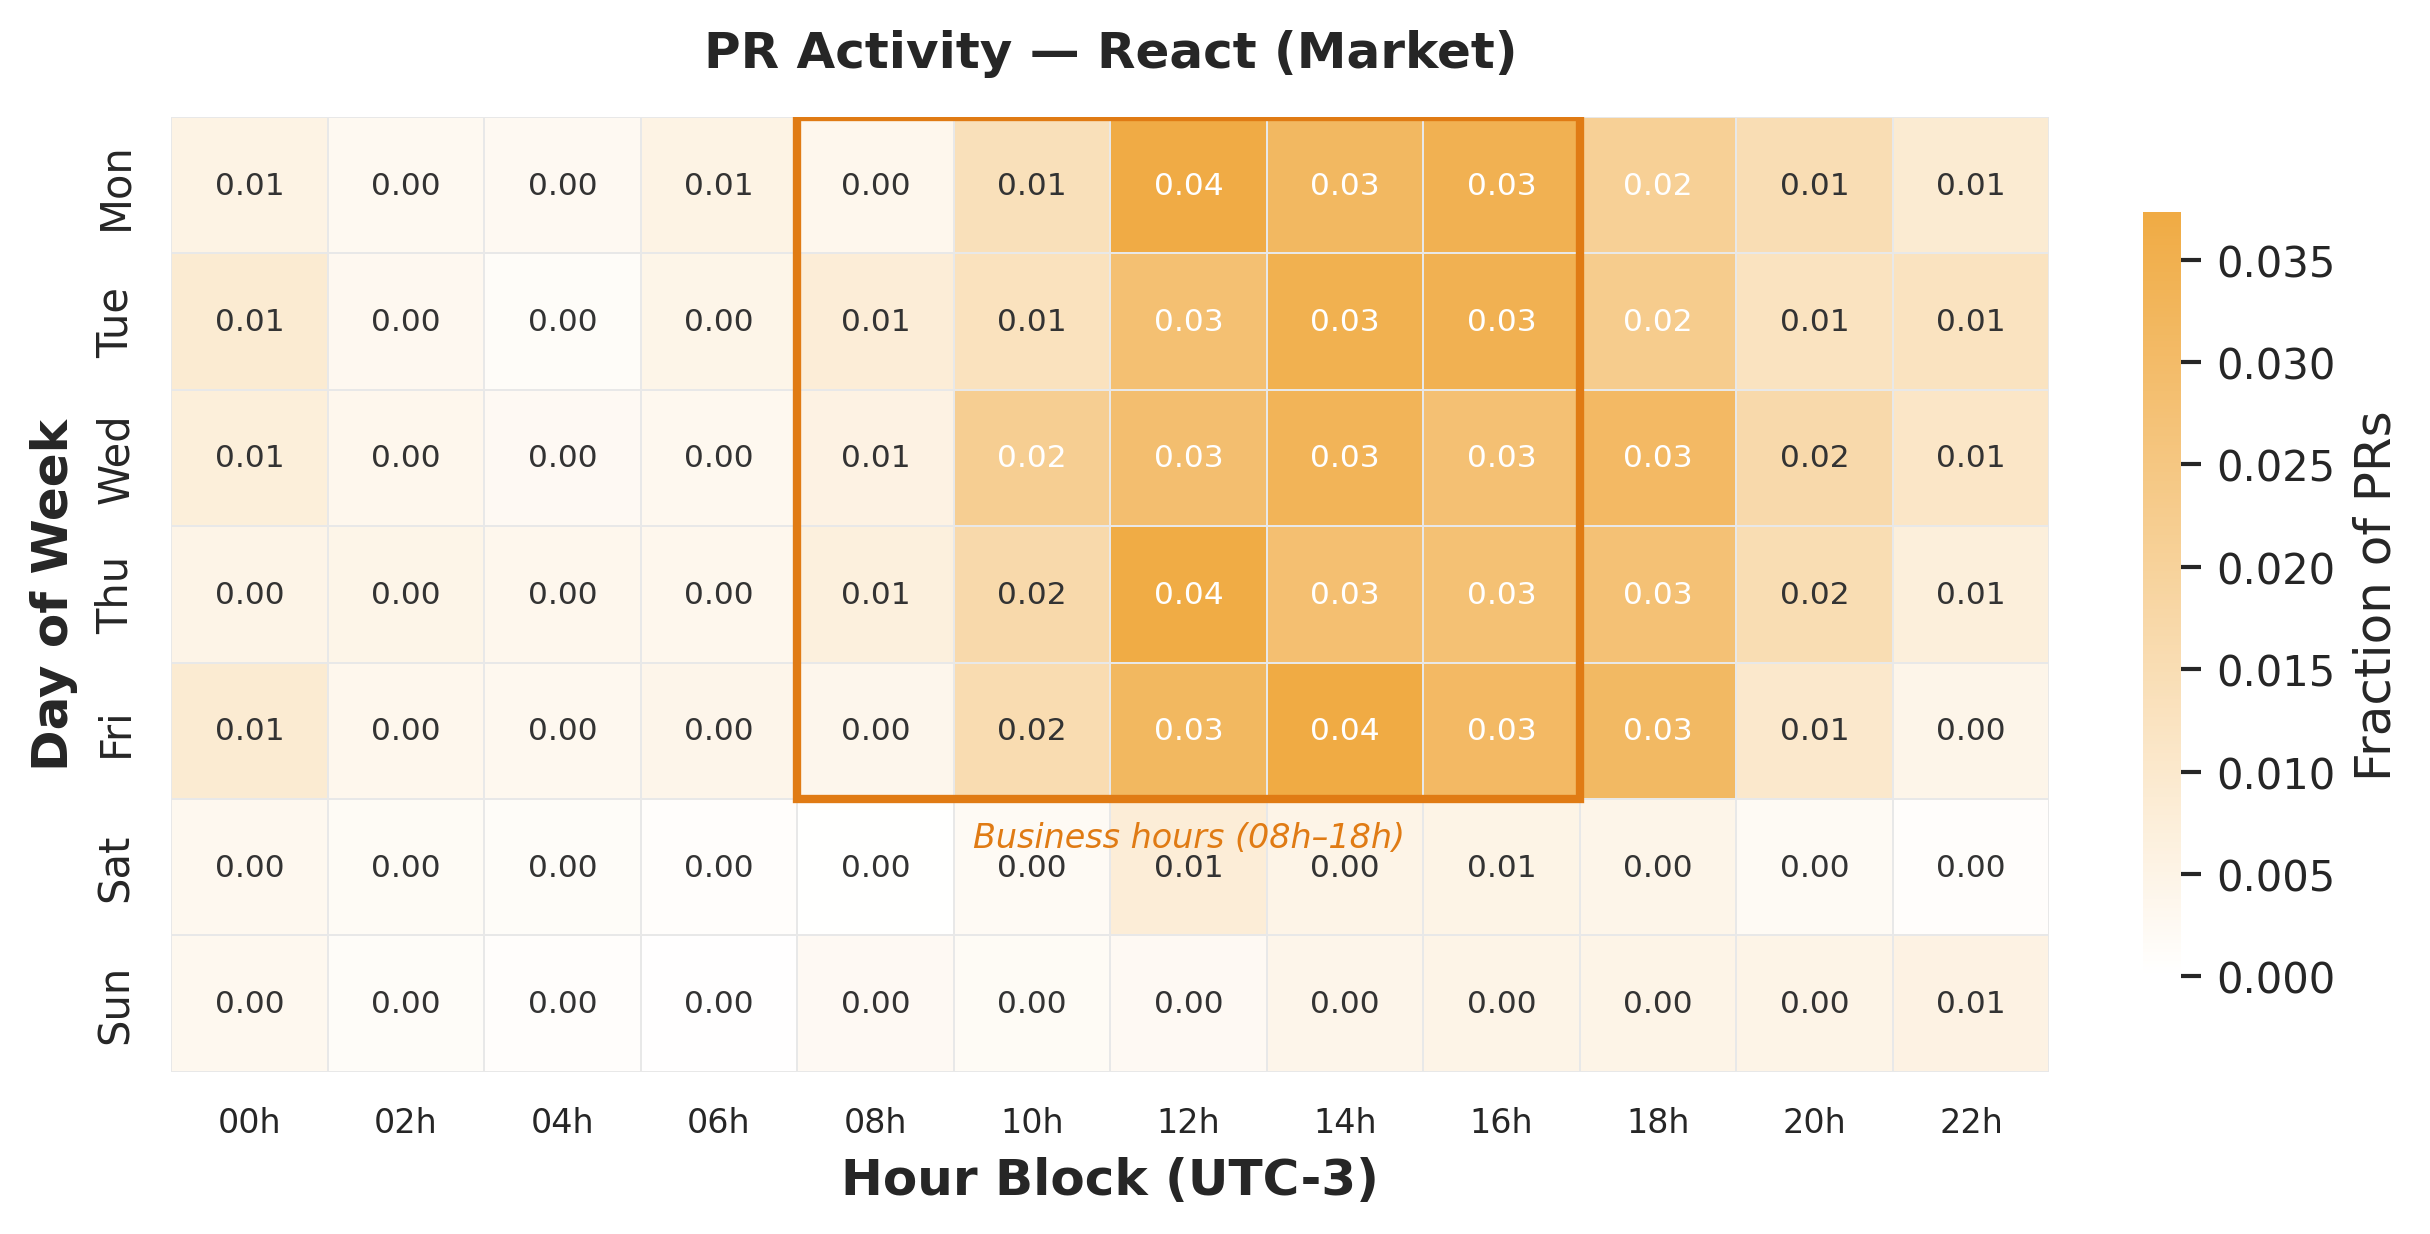

Saved: figures/pace_storm_market.pdf


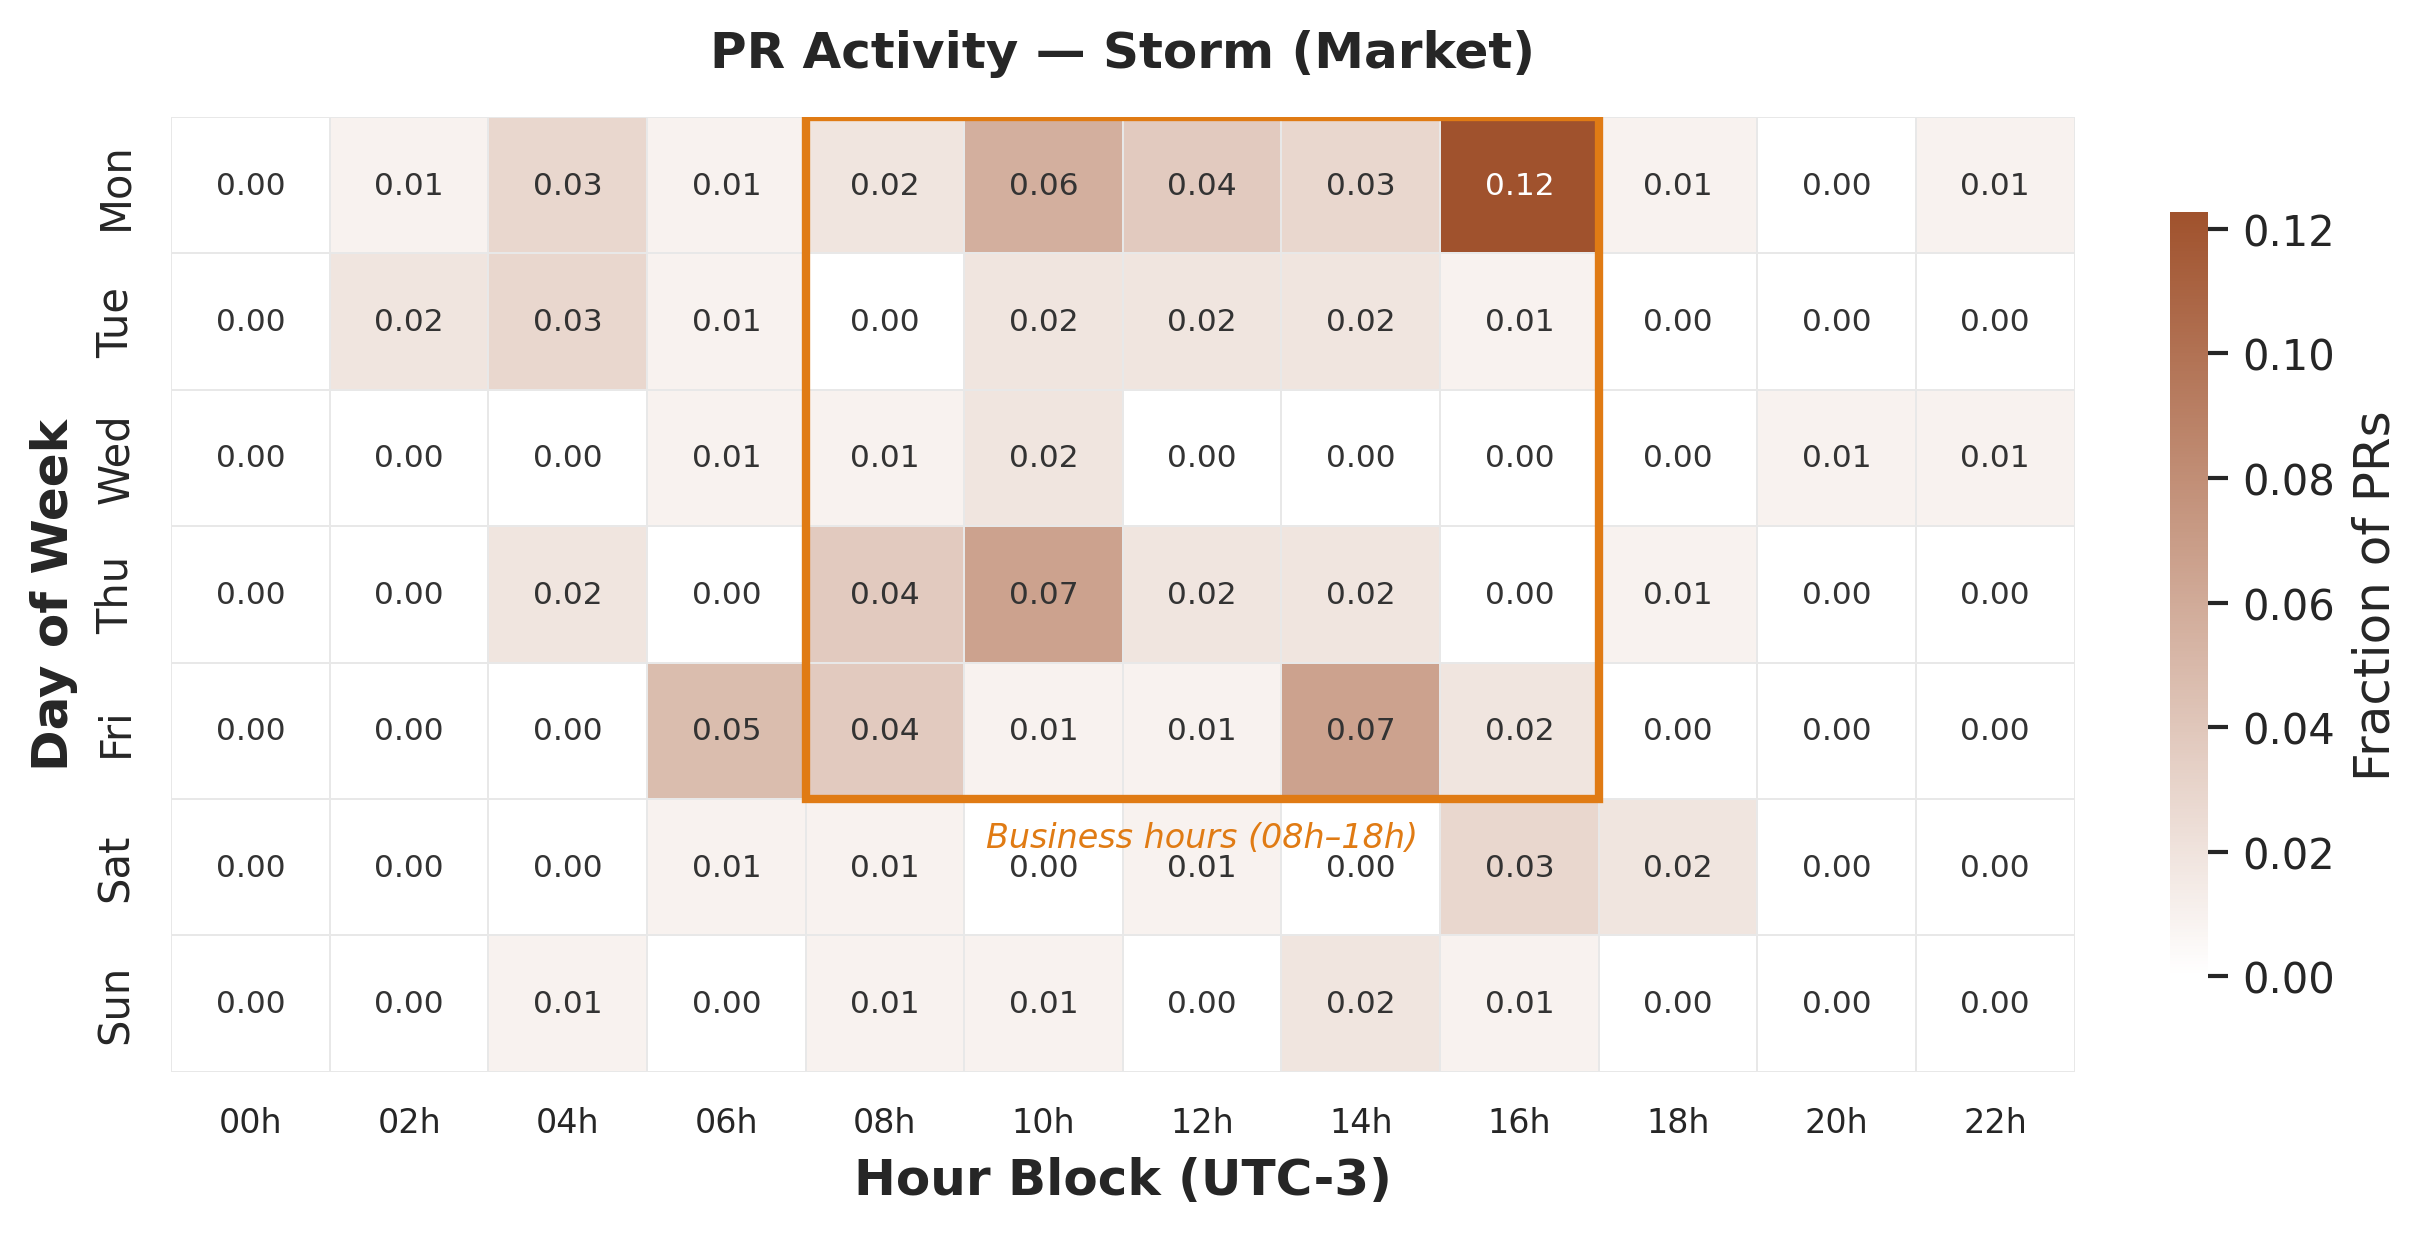

Saved: figures/pace_phoenix_market.pdf


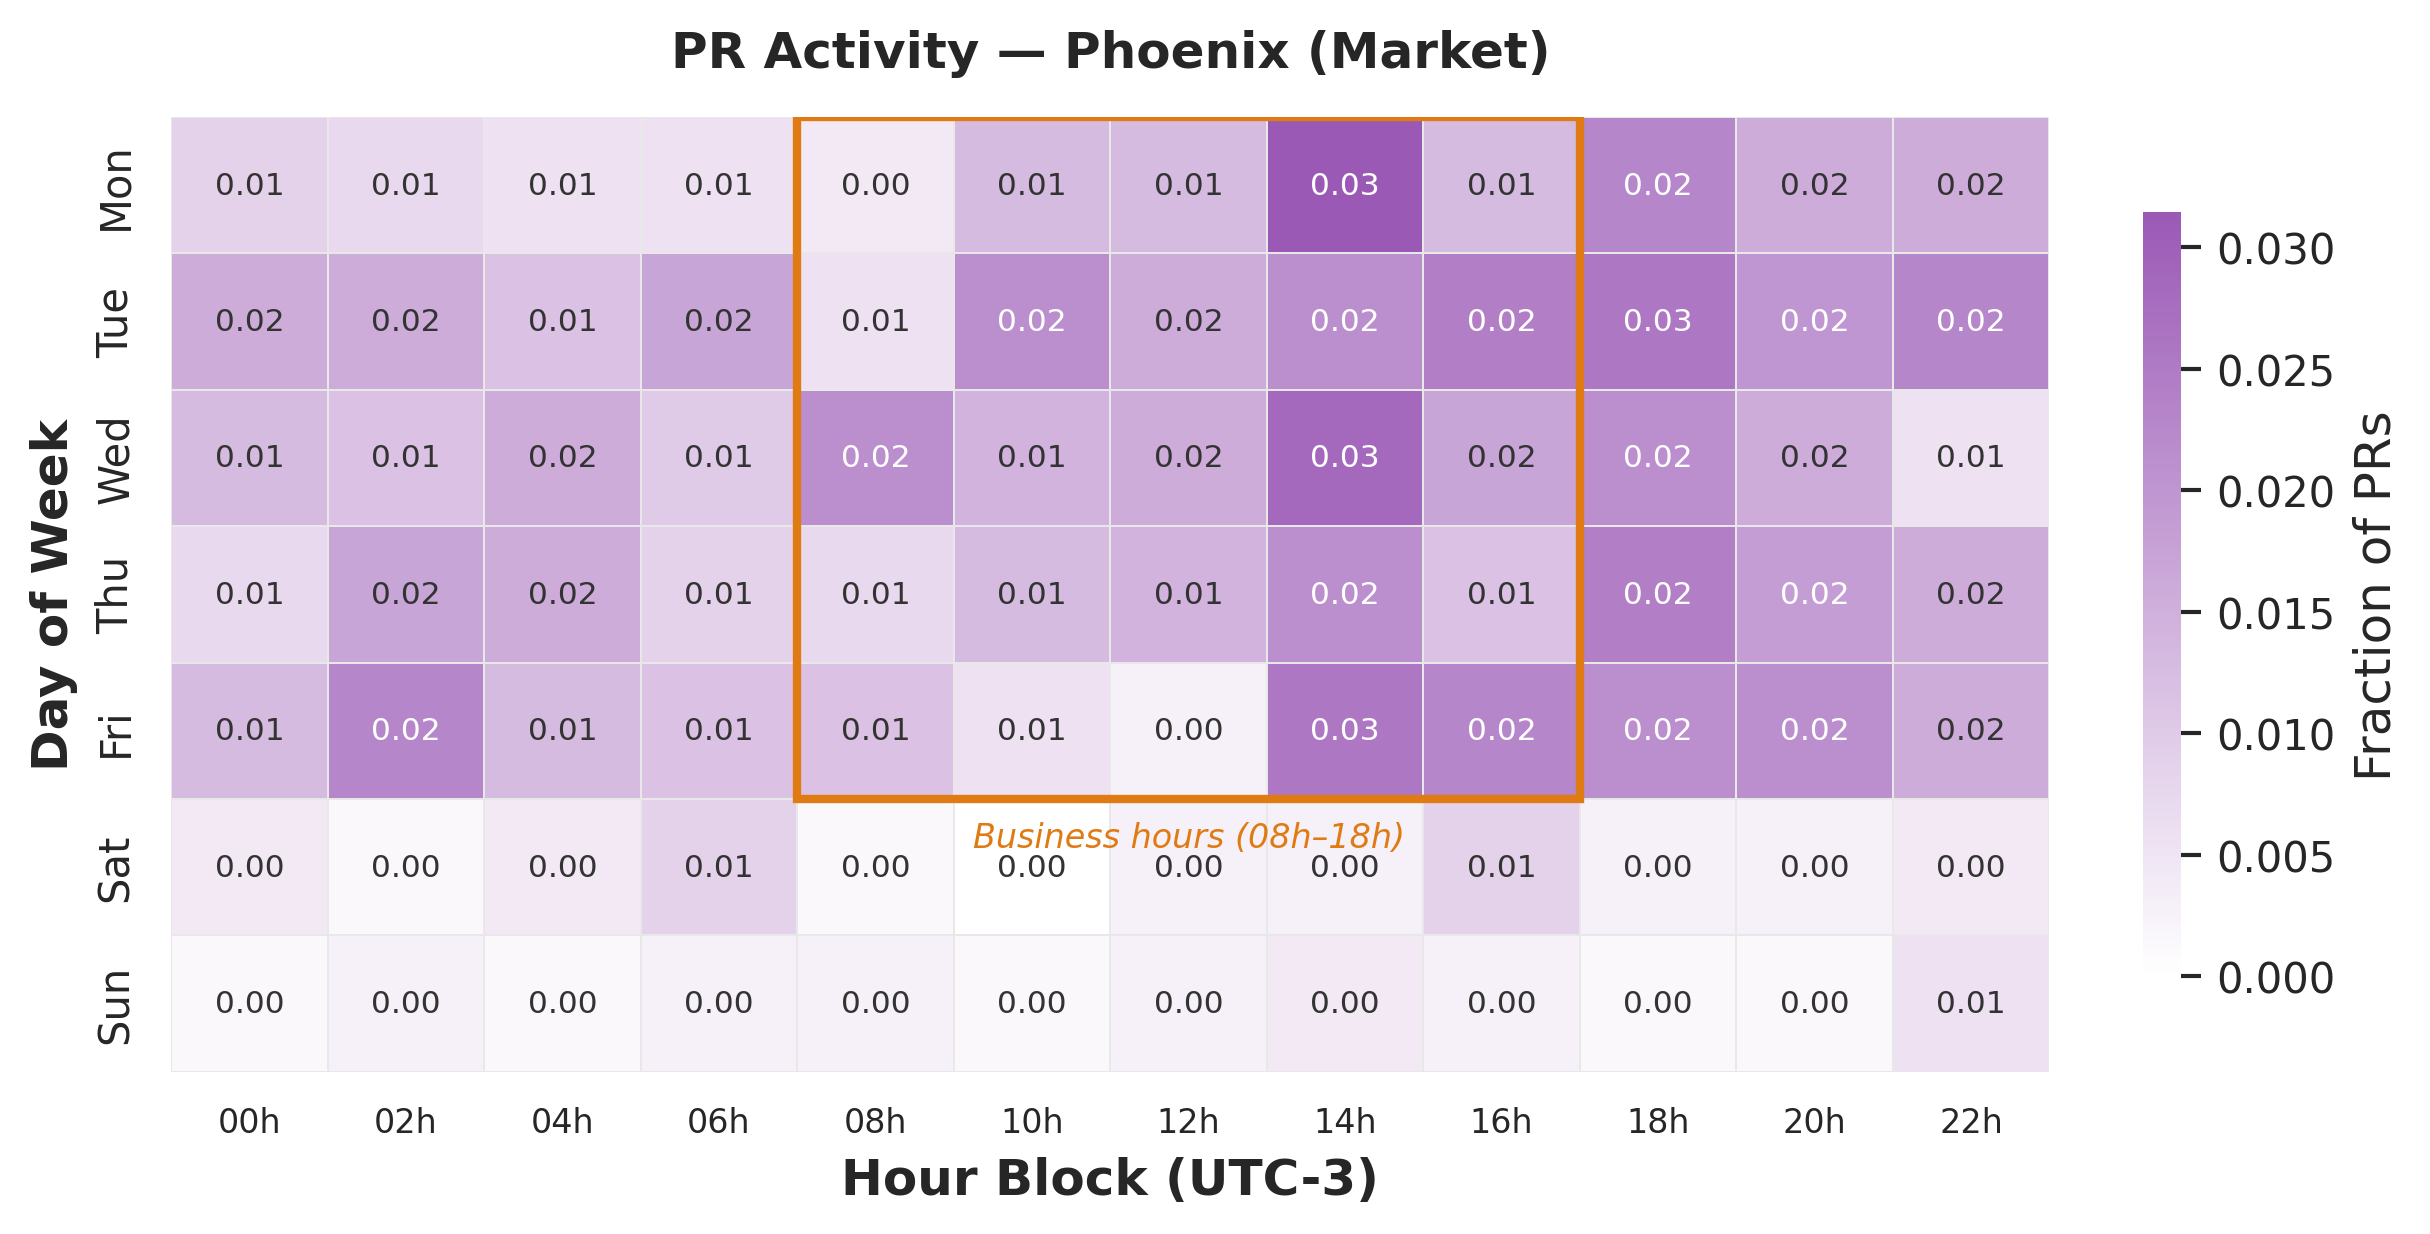

Saved: figures/pace_pulpcore_market.pdf


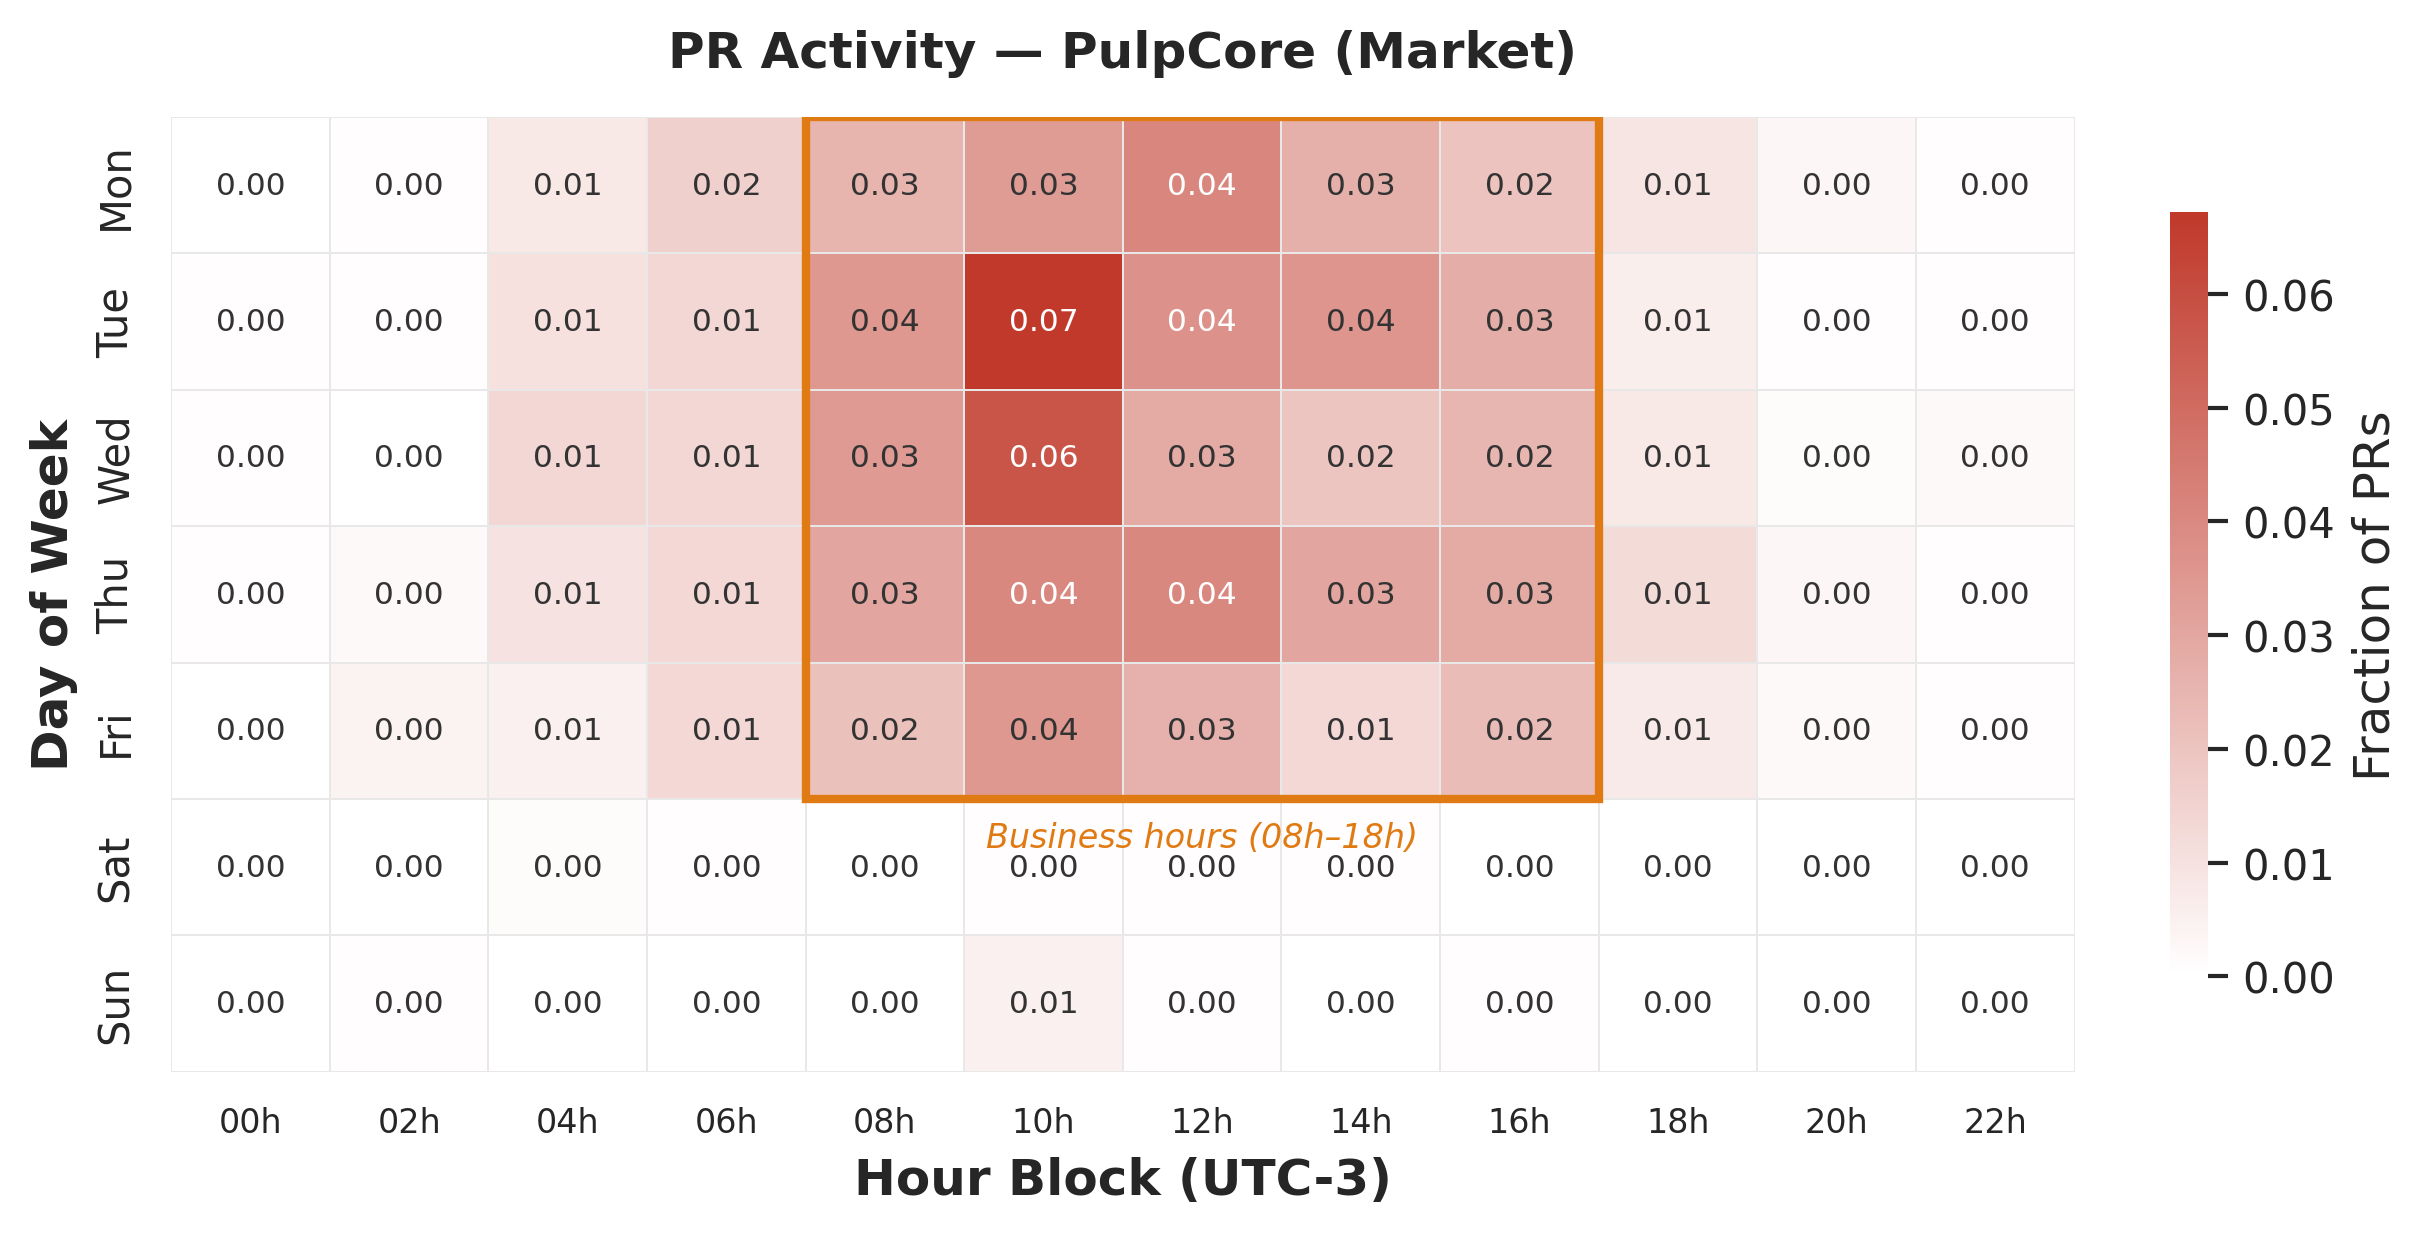

Saved: figures/pace_quay_market.pdf


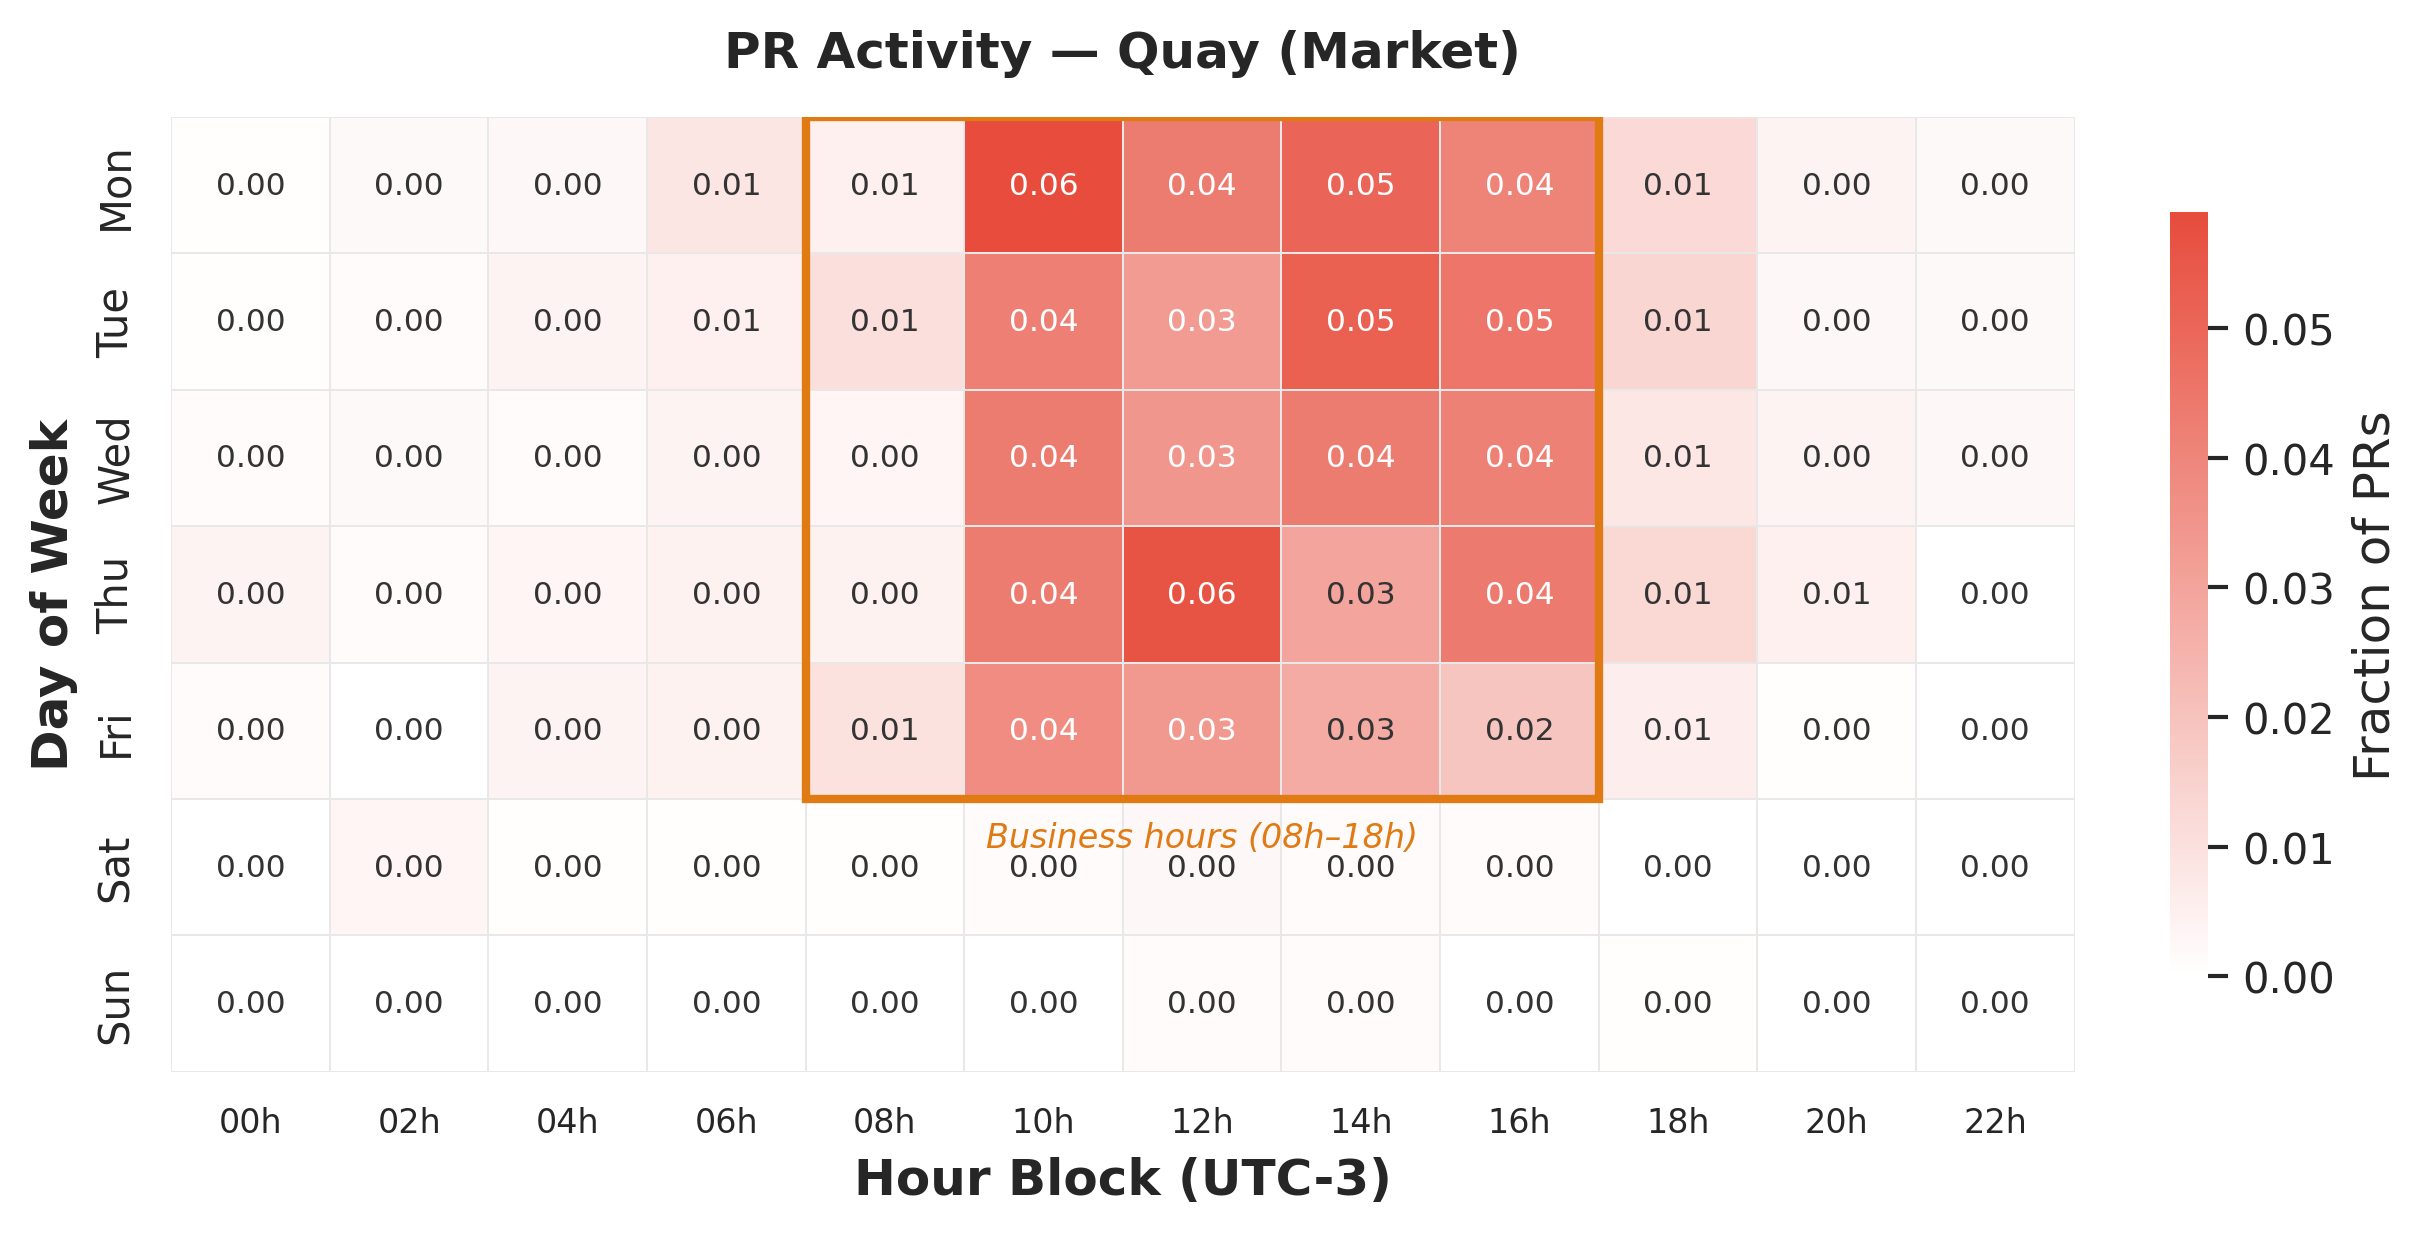

In [14]:
# Market repos — individual heatmaps
for mkt_label, color in [
    ('Decidim (Market)',    '#E07B14'),
    ('VSCode (Market)',     '#D55E00'),
    ('React (Market)',      '#F0AB44'),
    ('Storm (Market)',      '#A0522D'),
    ('Phoenix (Market)',    '#9B59B6'),
    ('PulpCore (Market)',   '#C0392B'),
    ('Quay (Market)',       '#E74C3C'),
]:
    slug = mkt_label.replace(' ', '_').replace('(', '').replace(')', '').lower()
    _ = plot_heatmap(
        groups[mkt_label],
        title=f'PR Activity — {mkt_label}',
        cmap_color=color,
        normalize=True,
        save_path=FIGURES_DIR / f'pace_{slug}.pdf',
    )

---
## 4  Knowledge Transfer

### Definição

Knowledge Transfer (KT) aqui é definido como a **aquisição gradual de familiaridade com a
base de código** ao longo do tempo de participação do desenvolvedor no projeto.
Um desenvolvedor "conhece" um arquivo se:
1. editou diretamente esse arquivo em alguma PR (contribuição direta); ou
2. revisou uma PR que tocou esse arquivo (exposição indireta).

A métrica de interesse é `mean_total`: o número médio de arquivos únicos conhecidos
(editados ou revisados) em função do tempo de projeto (medido em meses de "tenure").

### Melhorias desta versão

A versão conferência exibia apenas o BP. Esta versão adiciona:
- Curvas sobrepostas para todos os grupos com número de desenvolvedores suficiente.
- Banda de confiança (±1 desvio padrão) ao redor da média.
- Escala normalizada opcional: divide `mean_total` pelo número total de arquivos únicos do
  projeto, expressando KT como percentual do codebase.
- Gráfico separado por categoria (Government, Academic, Market) para clareza.

**Limitações:** para repositórios muito grandes,
o número de arquivos únicos é da ordem de dezenas de milhares. A curva de KT desses
repositórios reflete um crescimento absoluto diferente de projetos menores; por isso
a comparação normalizada é mais informativa.

In [15]:
def analyze_knowledge_growth(
    df_project: pd.DataFrame,
    min_devs: int = 3,
) -> tuple[pd.DataFrame, dict]:
    """
    Compute monthly knowledge accumulation per developer.

    Returns
    -------
    results      : DataFrame with one row per tenure-month containing aggregate stats
    dev_monthly  : raw per-developer monthly data (for inspection)
    """
    df = df_project.copy()
    df['created_at'] = pd.to_datetime(df['created_at'], utc=True, errors='coerce')
    df = df[df['created_at'].notna()].sort_values('created_at')

    dev_timeline: dict = {}

    # Authored PRs
    for _, row in df.iterrows():
        author = row['author']
        if pd.isna(author) or is_bot(author):
            continue
        fh = row.get('file_hashes', '')
        if pd.isna(fh) or fh == '':
            continue
        files = {h.strip() for h in str(fh).split(',') if h.strip()}
        ts    = row['created_at']
        if author not in dev_timeline:
            dev_timeline[author] = {'events': [], 'first': ts}
        dev_timeline[author]['events'].append({'ts': ts, 'edited': files, 'reviewed': set()})

    # Reviewed PRs
    for _, row in df.iterrows():
        rv_str = row.get('reviewers', '')
        if pd.isna(rv_str) or rv_str == '':
            continue
        fh = row.get('file_hashes', '')
        if pd.isna(fh) or fh == '':
            continue
        files     = {h.strip() for h in str(fh).split(',') if h.strip()}
        ts        = row['created_at']
        reviewers = [r.strip() for r in str(rv_str).split(',') if r.strip()]
        for reviewer in reviewers:
            if is_bot(reviewer):
                continue
            if reviewer not in dev_timeline:
                dev_timeline[reviewer] = {'events': [], 'first': ts}
            if ts < dev_timeline[reviewer]['first']:
                dev_timeline[reviewer]['first'] = ts
            dev_timeline[reviewer]['events'].append({'ts': ts, 'edited': set(), 'reviewed': files})

    dev_monthly: dict = {}
    for dev, data in dev_timeline.items():
        first  = data['first']
        events = sorted(data['events'], key=lambda e: e['ts'])
        edited_seen   = set()
        reviewed_seen = set()
        raw: dict = {}
        for ev in events:
            edited_seen.update(ev['edited'])
            reviewed_seen.update(ev['reviewed'])
            month = int((ev['ts'] - first).days / 30.44)
            raw[month] = {
                'edited':   len(edited_seen),
                'reviewed': len(reviewed_seen),
                'total':    len(edited_seen | reviewed_seen),
            }
        if not raw:
            continue
        # Forward-fill missing months
        filled: dict = {}
        prev = {'edited': 0, 'reviewed': 0, 'total': 0}
        for m in range(min(raw), max(raw) + 1):
            if m in raw:
                prev = raw[m]
            filled[m] = prev.copy()
        dev_monthly[dev] = filled

    all_months = sorted({m for dm in dev_monthly.values() for m in dm})
    results = []
    for month in all_months:
        vals = [dm[month] for dm in dev_monthly.values() if month in dm]
        if len(vals) < min_devs:
            continue
        results.append({
            'tenure_month': month,
            'n_devs':       len(vals),
            'mean_edited':   np.mean([v['edited']   for v in vals]),
            'mean_reviewed': np.mean([v['reviewed'] for v in vals]),
            'mean_total':    np.mean([v['total']    for v in vals]),
            'std_total':     np.std( [v['total']    for v in vals]),
        })

    return pd.DataFrame(results), dev_monthly

Computing Knowledge Transfer for Brasil Participativo...
  22 months of data
Saved: kt_bp_decomposed.pdf


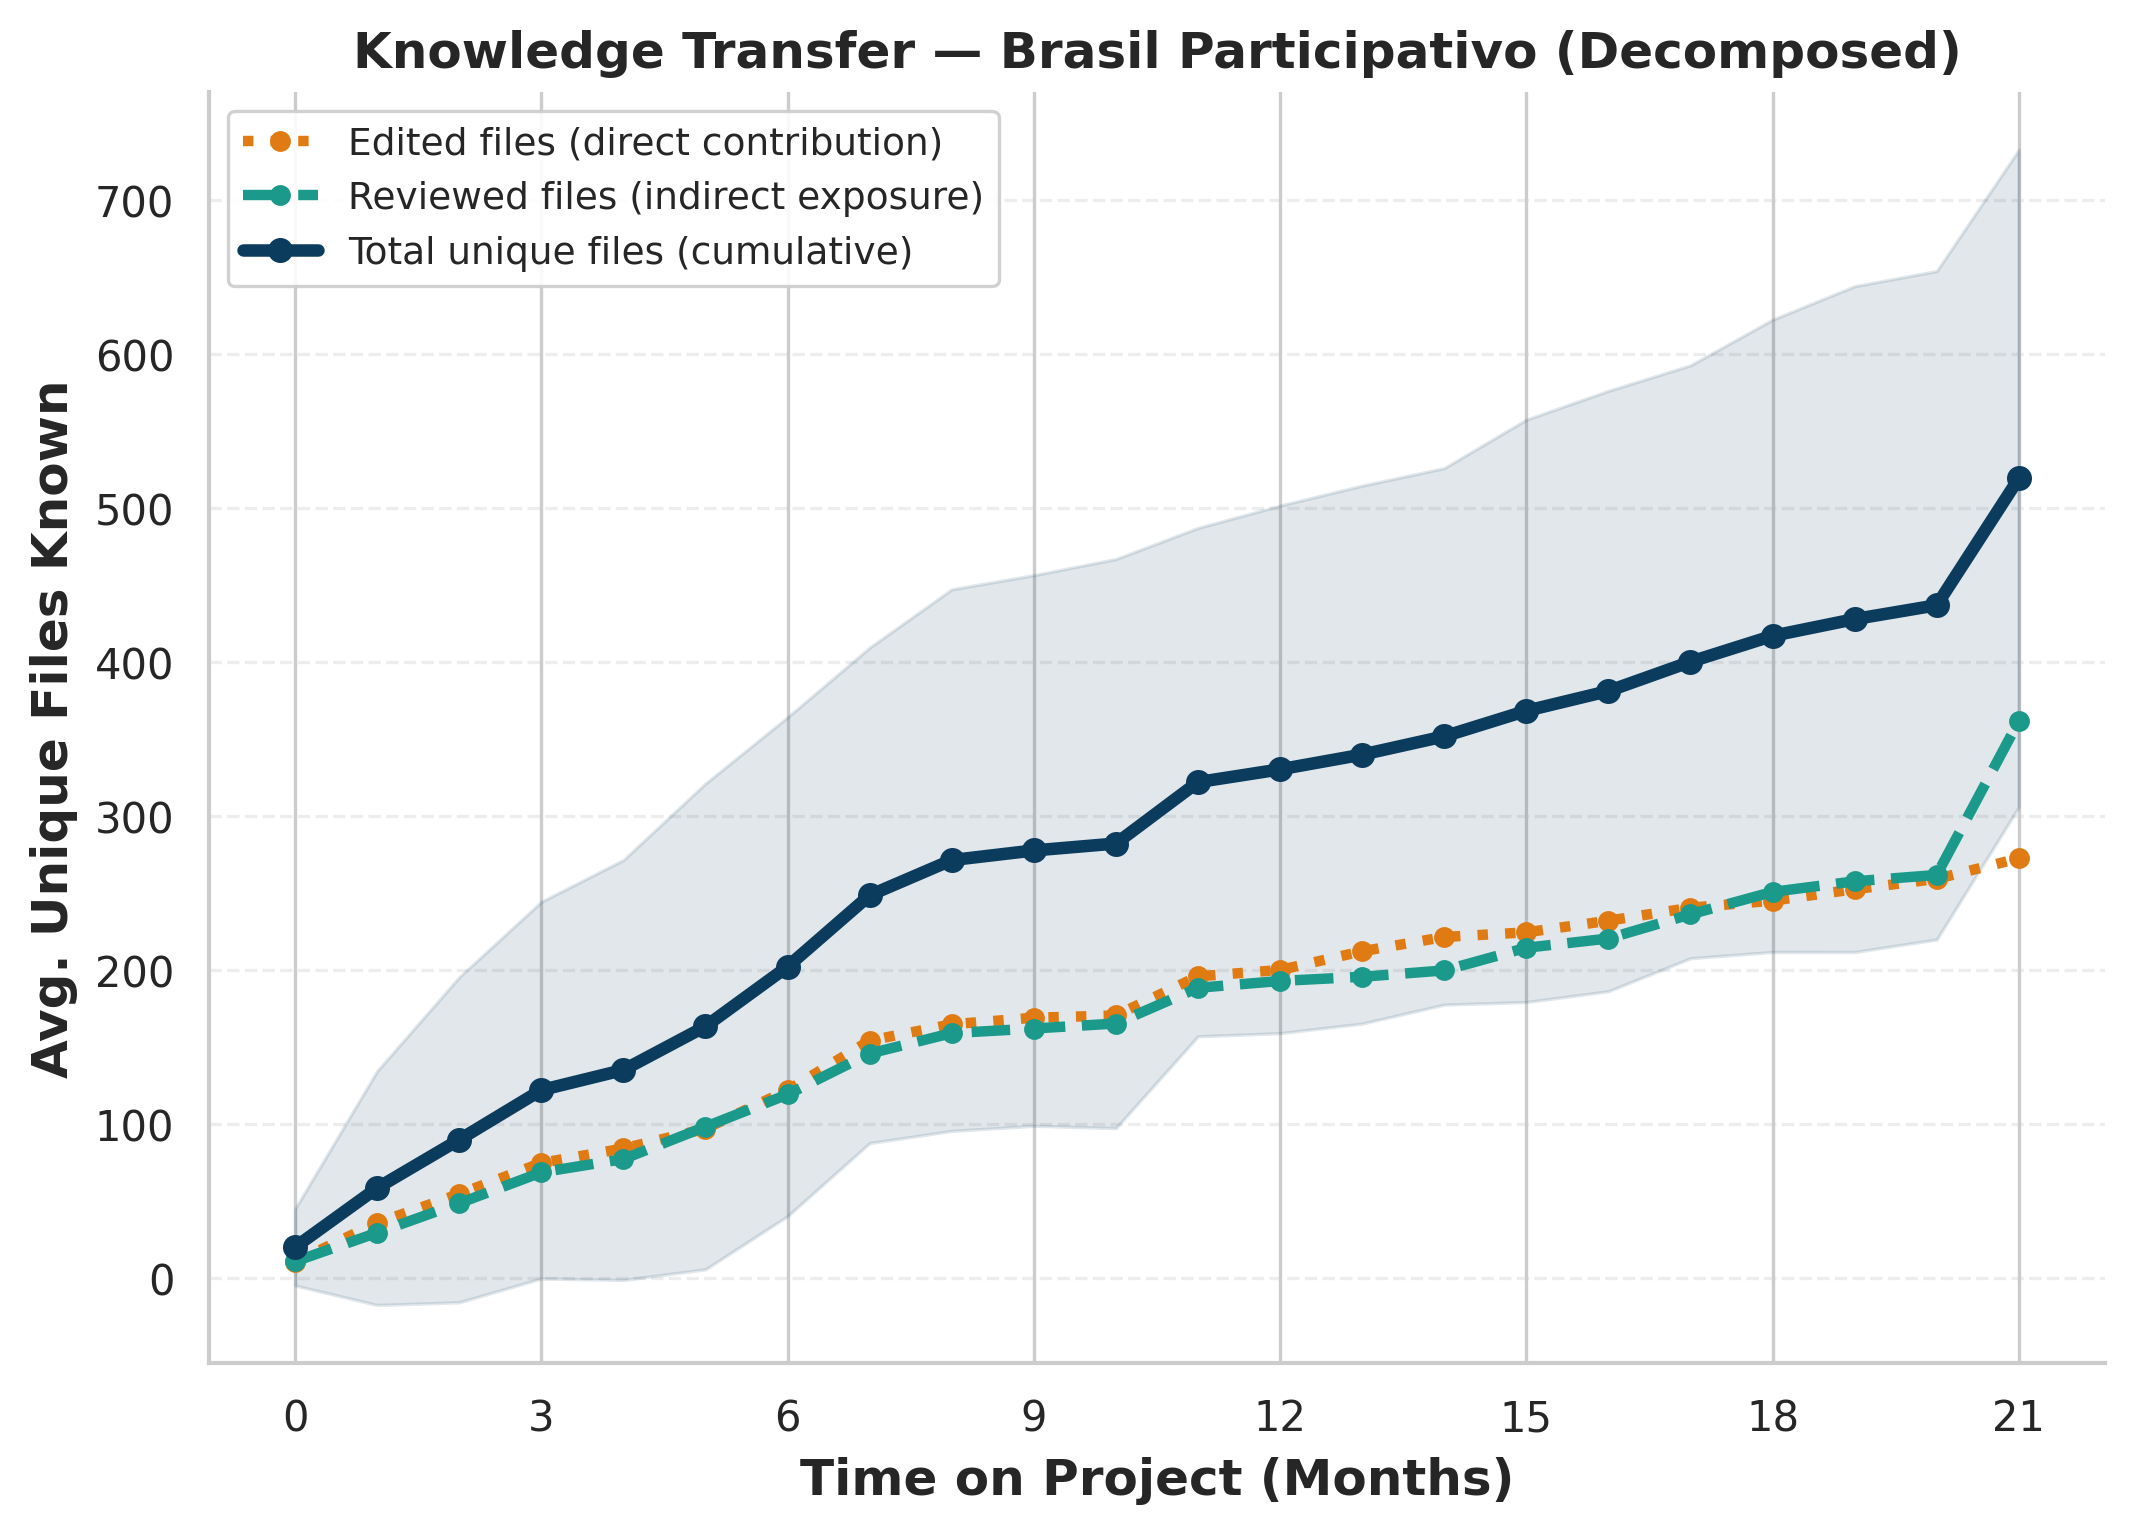

In [16]:
# Compute KT for BP only (deep dive)
print('Computing Knowledge Transfer for Brasil Participativo...')
res_bp, _ = analyze_knowledge_growth(groups['Brasil Participativo'], min_devs=3)
print(f'  {len(res_bp)} months of data')

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(res_bp['tenure_month'], res_bp['mean_edited'],
        color=MKT_PRIMARY, linestyle=':', linewidth=2.5,
        marker='o', markersize=4, label='Edited files (direct contribution)')
ax.plot(res_bp['tenure_month'], res_bp['mean_reviewed'],
        color=ACAD_PRIMARY, linestyle='--', linewidth=2.5,
        marker='o', markersize=4, label='Reviewed files (indirect exposure)')
ax.plot(res_bp['tenure_month'], res_bp['mean_total'],
        color=BP_PRIMARY, linestyle='-', linewidth=3,
        marker='o', markersize=5, label='Total unique files (cumulative)')

ax.fill_between(res_bp['tenure_month'],
                res_bp['mean_total'] - res_bp['std_total'],
                res_bp['mean_total'] + res_bp['std_total'],
                color=BP_PRIMARY, alpha=0.12)

ax.set_xlabel('Time on Project (Months)', fontweight='bold')
ax.set_ylabel('Avg. Unique Files Known', fontweight='bold')
ax.set_title('Knowledge Transfer — Brasil Participativo (Decomposed)', fontweight='bold')

ax.xaxis.set_major_locator(ticker.MultipleLocator(3))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.legend(loc='upper left', frameon=True, framealpha=0.9, fontsize=9)

fig.savefig(FIGURES_DIR / 'kt_bp_decomposed.pdf', bbox_inches='tight')
print('Saved: kt_bp_decomposed.pdf')
plt.show()

---
## 5  Summary of Methodological Choices

| Section | Visualization | Key Choice | Rationale |
|---|---|---|---|
| LOC / Files | Violin + inner box | Log₁₀ scale | Software size metrics are log-normally distributed; log scale linearizes the distribution shape and prevents large repos from collapsing the y-axis. |
| LOC / Files | Violin + inner box | 99th pct clipping | Extreme outliers (e.g., single dependency-update PRs with 100k+ LOC) compress the main distribution into a flat line if not clipped. The clipping threshold is reported on the figure. |
| Refactoring | Violin | No log scale | Ratio in [0,1]; no heavy tail; log scale would distort the interpretation. |
| Pace | Heatmap | Normalized by total for cross-group | Groups have very different PR volumes; fraction-based heatmaps allow visual comparison of activity patterns irrespective of size. |
| KT | Line + band | Absolute count | The absolute curve reveals *how many* files a developer typically knows after N months, which is directly interpretable. The rate-of-learning chart complements it. |
| KT | Rate chart | 3-month rolling avg. | Month-level deltas are noisy; smoothing reveals the underlying trend without over-smoothing. |

### Limitations

1. **File hashes as proxy for file identity**: `file_hashes` are computed at extraction time.
   Renaming or moving files creates a new hash, breaking continuity. This may underestimate
   knowledge in repos with heavy refactoring.
2. **Knowledge Transfer excludes commit-level data**: The analysis relies only on PR-level
   metadata (which files were touched per PR), not individual commit diffs.
3. **Very large repos omitted from KT**: Their file counts (10k–100k) make
   absolute comparison with academic repos (100–500 files) misleading. A normalized KT curve
   would require knowing the total unique files in each repository, which is not available
   from PR-level data alone.
4. **Bot classification is keyword-based**: Conservative list may miss project-specific bots.